In [1]:
import os
import sys

if 'COLAB_RELEASE_TAG' in os.environ:
    print("Detected Google Colab. Cloning repository to fetch data...")
    repo_url = "https://github.com/jt3645-arch/Medical-Radiologist-AI-Agent"

    repo_name = "Medical-Radiologist-AI-Agent"

    if not os.path.exists(repo_name):
        !git clone {repo_url}

    %cd {repo_name}

    print("Installing requirements...")
    !pip install -r requirements.txt
    print("Setup complete! Ready to run.")

BASE_DIR = '.'
DATA_DIR = os.path.join(BASE_DIR, 'data')
OUT_DIR  = os.path.join(BASE_DIR, 'outputs_doc')
os.makedirs(OUT_DIR, exist_ok=True)

Detected Google Colab. Cloning repository to fetch data...
Cloning into 'Medical-Radiologist-AI-Agent'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 60 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (60/60), 4.63 MiB | 17.42 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/Medical-Radiologist-AI-Agent
Installing requirements...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 42.7 MB/s eta 0:00:00
Setup complete! Ready to run.


In [2]:
import h5py
from scipy.io import loadmat
import numpy as np
import os
from scipy.ndimage import binary_fill_holes, distance_transform_edt
from skimage.filters import gaussian, threshold_otsu, sobel
from skimage.morphology import (
    disk, binary_closing, binary_erosion, binary_dilation,
    remove_small_objects
)
from skimage.feature import canny
from skimage.measure import label, regionprops
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.util import img_as_ubyte

import matplotlib.pyplot as plt

np.random.seed(2025)

DEMO_MODE = True
MAX_FILES = 10

files = [f for f in os.listdir(DATA_DIR) if f.lower().endswith('.mat')]
if len(files) == 0:
    raise FileNotFoundError(f'No .mat files found in {DATA_DIR}')
files.sort(key=lambda x: (len(x), x))

if DEMO_MODE:
    files = files[:MAX_FILES]
    print(f"Note: Demo mode (DEMO_MODE) is enabled. For quick reproduction, only the front end is currently processed.")
    print(f"To run the full dataset, set DEMO_MODE to False.")

N = len(files)
print(f'Found {N} MAT files.')

# Parameters
class PObj: pass
P = PObj()

P.K = 4
P.maxIter = 60

P.gaussSigma = 1.0

P.minArea = 30
P.keepLargest = True
P.clearBorder = False

P.cannySigma = 1.2

P.minFrac = 0.002
P.maxFrac = 0.25

P.forbidBand = 20
P.edgeMinArea = 25

P.contrastWeight      = 1.10
P.distWeight          = 0.45
P.solidityWeight      = 0.55

P.ringPenaltyWeight   = 1.22
P.rimFracWeight       = 1.10
P.overlapWeight       = 0.15

P.ringRadius = 6
P.edgeDilate = 1

P.minOverlapToKeep = 0.00
P.verbose = False

P.areaFracTarget = np.sqrt(P.minFrac * P.maxFrac)
P.areaFracPenaltyWeight = 0.10

P.minFracGateFactor = 0.60
P.maxFracGateFactor = 1.10
P.rimHinge = 0.20
P.thinnessWeight = 0.12

Note: Demo mode (DEMO_MODE) is enabled. For quick reproduction, only the front end is currently processed.
To run the full dataset, set DEMO_MODE to False.
Found 10 MAT files.


In [3]:
def _load_mat(fp):
    try:
        return loadmat(fp, struct_as_record=False, squeeze_me=True), 'v7'
    except NotImplementedError:
        return None, 'v7.3'

def _h5_read(fp):
    return h5py.File(fp, 'r')

def _matlab_struct_get(obj, field):
    if obj is None:
        return None
    if hasattr(obj, field):
        return getattr(obj, field)
    if isinstance(obj, dict) and field in obj:
        return obj[field]
    return None

def _extract_cjdata(mat):
    if 'cjdata' not in mat:
        return None
    return mat['cjdata']

def toGrayDouble(I):
    I = np.array(I)
    if I.ndim == 3:
        Igray = rgb2gray(I)
    else:
        Igray = I.astype(np.float64)
    if Igray.dtype.kind in ('u', 'i'):
        maxv = np.iinfo(Igray.dtype).max
        Igray = Igray.astype(np.float64) / maxv
    else:
        Igray = Igray.astype(np.float64)
    return Igray

def postProcessMask_soft(m, P):
    m = binary_closing(m, disk(2))
    m = binary_fill_holes(m)
    m = remove_small_objects(m.astype(bool), min_size=P.minArea)
    if P.clearBorder:

        pass
    return m.astype(bool)

def _keep_largest_component(mask):
    lbl = label(mask)
    if lbl.max() == 0:
        return mask.astype(bool)
    areas = np.bincount(lbl.ravel())
    areas[0] = 0
    k = areas.argmax()
    return (lbl == k)

def toBinaryMaskRobust(gt, targetSize):
    gt = np.array(gt)
    if gt.ndim == 3:
        gt = rgb2gray(gt)
    if (gt.shape[0] != targetSize[0]) or (gt.shape[1] != targetSize[1]):
        gt = resize(gt, (targetSize[0], targetSize[1]),
                    order=0, preserve_range=True, anti_aliasing=False).astype(gt.dtype)
    if gt.dtype == bool:
        return gt
    gtd = gt.astype(np.float64)
    mx = np.max(gtd) if gtd.size else 0
    if mx <= 1:
        gtMask = gtd > 0.5
    elif mx <= 10:
        gtMask = gtd > 0
    else:
        gtMask = gtd > 127
    return gtMask.astype(bool)

def segMetrics(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    tp = np.count_nonzero(pred & gt)
    fp = np.count_nonzero(pred & ~gt)
    fn = np.count_nonzero(~pred & gt)
    dice = (2*tp) / (2*tp + fp + fn + np.finfo(float).eps)
    iou  = tp / (tp + fp + fn + np.finfo(float).eps)
    prec = tp / (tp + fp + np.finfo(float).eps)
    rec  = tp / (tp + fn + np.finfo(float).eps)
    return dice, iou, prec, rec

def _bwperim(mask):
    mask = mask.astype(bool)
    er = binary_erosion(mask, disk(1))
    return mask & ~er

def exportTopPNG(outPng, I, pred, titleText, diceVal):
    Igray = toGrayDouble(I)

    fig = plt.figure(figsize=(7, 7), dpi=110)
    gs = fig.add_gridspec(2, 1, hspace=0.15)

    ax = fig.add_subplot(gs[0, 0])
    ax.imshow(Igray, cmap='gray')
    ax.set_title('Original')
    ax.axis('off')

    ax = fig.add_subplot(gs[1, 0])
    ax.imshow(pred, cmap='gray')
    ax.set_title(f'Pred Mask | Dice={diceVal:.4f}')
    ax.axis('off')

    fig.suptitle(titleText)
    fig.savefig(outPng, dpi=220, bbox_inches='tight')
    plt.close(fig)
    print(f'Saved: {outPng}')

def kmeans_then_canny_inner_dist_ring(I, P):
    Igray = toGrayDouble(I)
    Igray = gaussian(Igray, sigma=P.gaussSigma, preserve_range=True)

    mn = float(np.min(Igray))
    mx = float(np.max(Igray))
    if mx > mn:
        Igray = (Igray - mn) / (mx - mn)
    else:
        return np.zeros_like(Igray, dtype=bool), np.zeros_like(Igray, dtype=bool)

    # remove black background
    nz = Igray[Igray > 0]
    thr = 0.02
    if nz.size > 0:
        try:
            thr = max(0.01, float(threshold_otsu(nz)) * 0.7)
        except Exception:
            thr = 0.02

    brain = Igray > thr
    brain = binary_closing(brain, disk(6))
    brain = binary_fill_holes(brain)
    brain = _keep_largest_component(brain)

    # Outer rim band
    coreErode = binary_erosion(brain, disk(P.forbidBand))
    if np.count_nonzero(coreErode) < 800:
        coreErode = binary_erosion(brain, disk(max(6, int(round(P.forbidBand / 2)))))
    if np.count_nonzero(coreErode) < 300:
        coreErode = brain.copy()

    rimBand = brain & ~coreErode
    core = brain & ~rimBand


    Iedge = gaussian(Igray, sigma=1.4, preserve_range=True)
    G = np.abs(sobel(Iedge))
    gvals = G[core]
    gthr = 0.0 if gvals.size == 0 else float(np.percentile(gvals, 85))
    strongG = (G >= gthr)

    edgeI = canny(Iedge, sigma=P.cannySigma)
    edgeI = edgeI & strongG & core
    edgeI = remove_small_objects(edgeI, min_size=P.edgeMinArea)

    edgeForOverlap = edgeI.copy()
    if P.edgeDilate > 0:
        edgeForOverlap = binary_dilation(edgeForOverlap, disk(P.edgeDilate))

    # Distance map: distance to brain boundary
    distMap = distance_transform_edt(brain)
    distMap = distMap / (np.max(distMap) + np.finfo(float).eps)

    # KMeans inside brain
    X = Igray[brain].reshape(-1, 1)
    if X.size == 0:
        return np.zeros_like(Igray, dtype=bool), edgeI.astype(bool)

    Xq = X.copy()
    xmin = float(Xq.min())
    xmax = float(Xq.max())
    if xmax > xmin:
        nb = 256
        Xq = np.round((Xq - xmin) / (xmax - xmin) * (nb - 1))
    else:
        Xq = np.zeros_like(Xq)

    try:
        from sklearn.cluster import KMeans
        km = KMeans(
            n_clusters=P.K,
            init='k-means++',
            n_init=1,
            max_iter=P.maxIter,
            algorithm='lloyd',
            random_state=2025
        )
        idx = km.fit_predict(Xq)
    except Exception:
        return np.zeros_like(Igray, dtype=bool), edgeI.astype(bool)

    L = np.zeros_like(Igray, dtype=np.int32)
    L[brain] = (idx + 1)

    bestScore = -np.inf
    best = np.zeros_like(Igray, dtype=bool)
    bestOverlap = 0.0

    def _score_components(regionMask, regionN_local, rimWeightScale=1.0):
        nonlocal bestScore, best, bestOverlap
        for k in range(1, P.K + 1):
            base = (L == k) & brain

            cand0 = base & regionMask
            cand0 = postProcessMask_soft(cand0, P)
            if np.count_nonzero(cand0) == 0:
                continue

            lbl = label(cand0)
            if lbl.max() == 0:
                continue

            for rp in regionprops(lbl):
                comp = (lbl == rp.label)
                areaA = int(rp.area)
                if areaA < P.minArea:
                    continue

                frac = areaA / max(regionN_local, 1)

                if frac < P.minFrac * P.minFracGateFactor or frac > P.maxFrac * P.maxFracGateFactor:
                    continue

                per = _bwperim(comp)
                denom = int(np.count_nonzero(per))
                if denom == 0:
                    continue

                overlap = np.count_nonzero(per & edgeForOverlap) / (denom + np.finfo(float).eps)
                meanDist = float(np.mean(distMap[comp])) if areaA > 0 else 0.0
                ringness = denom / (areaA + np.finfo(float).eps)

                solidity = float(rp.solidity)

                ring = binary_dilation(comp, disk(P.ringRadius)) & brain & ~comp
                if np.count_nonzero(ring) > 30:
                    contrast = float(np.mean(Igray[comp]) - np.mean(Igray[ring]))
                else:
                    contrast = 0.0

                rimFrac = np.count_nonzero(comp & rimBand) / (areaA + np.finfo(float).eps)

                fracSafe = max(frac, np.finfo(float).eps)
                areaPenalty = P.areaFracPenaltyWeight * (np.log(fracSafe / P.areaFracTarget) ** 2)

                rimPenalty = (P.rimFracWeight * rimWeightScale) * max(
                    0.0, (rimFrac - P.rimHinge) / (1.0 - P.rimHinge)
                )

                thinness = (denom ** 2) / (4.0 * np.pi * areaA + np.finfo(float).eps)
                thinPenalty = P.thinnessWeight * np.log(thinness + np.finfo(float).eps)

                score = (
                    P.contrastWeight    * contrast +
                    P.distWeight        * meanDist +
                    P.solidityWeight    * solidity +
                    P.overlapWeight     * overlap  -
                    P.ringPenaltyWeight * ringness -
                    rimPenalty          -
                    areaPenalty         -
                    thinPenalty         -
                    0.00002             * denom
                )

                if score > bestScore:
                    bestScore = score
                    best = comp
                    bestOverlap = overlap

    # Score inside core
    _score_components(core, int(np.count_nonzero(core)), rimWeightScale=1.0)

    # Fallback: score inside brain
    if bestScore == -np.inf:
        _score_components(brain, int(np.count_nonzero(brain)), rimWeightScale=1.6)

    predMask = best.astype(bool)
    predMask = predMask & ~rimBand

    if P.minOverlapToKeep > 0 and bestOverlap < P.minOverlapToKeep:
        predMask = np.zeros_like(Igray, dtype=bool)

    if P.keepLargest and np.count_nonzero(predMask) > 0:
        predMask = _keep_largest_component(predMask)

    return predMask, edgeI.astype(bool)

In [4]:
import pandas as pd
names = np.array(files, dtype=object)
Dice  = np.full(N, np.nan, dtype=float)
IoU   = np.full(N, np.nan, dtype=float)
Prec  = np.full(N, np.nan, dtype=float)
Rec   = np.full(N, np.nan, dtype=float)

TOPK = min(10, N)
top = [{"dice": -np.inf, "name": "", "I": None, "pred": None} for _ in range(TOPK)]

valid_count = 0

for i in range(N):
    fp = os.path.join(DATA_DIR, files[i])

    mat, kind = _load_mat(fp)
    I = None
    gt = None

    if kind == 'v7':
        cj = _extract_cjdata(mat)
        if cj is None:
            if (i < 10) or ((i+1) % 200 == 0) or (i+1 == N):
                print(f'[{i+1}/{N}] {files[i]} | no cjdata.image')
            continue

        I = _matlab_struct_get(cj, 'image')
        if I is None:
            if (i < 10) or ((i+1) % 200 == 0) or (i+1 == N):
                print(f'[{i+1}/{N}] {files[i]} | no cjdata.image')
            continue

        gt = _matlab_struct_get(cj, 'tumorMask')

    else:

        with _h5_read(fp) as f:
            if 'cjdata' not in f:
                if (i < 10) or ((i+1) % 200 == 0) or (i+1 == N):
                    print(f'[{i+1}/{N}] {files[i]} | no cjdata.image')
                continue
            cj = f['cjdata']
            if 'image' not in cj:
                if (i < 10) or ((i+1) % 200 == 0) or (i+1 == N):
                    print(f'[{i+1}/{N}] {files[i]} | no cjdata.image')
                continue

            I = np.array(cj['image'])
            if I.ndim >= 2:
                I = np.transpose(I)

            if 'tumorMask' in cj:
                gt = np.array(cj['tumorMask'])
                if gt.ndim >= 2:
                    gt = np.transpose(gt)
            else:
                gt = None

    pred, _edgeI = kmeans_then_canny_inner_dist_ring(I, P)

    if gt is not None and np.size(gt) > 0:
        valid_count += 1
        gt = toBinaryMaskRobust(gt, pred.shape)
        d, j, p, r = segMetrics(pred, gt)
        Dice[i], IoU[i], Prec[i], Rec[i] = d, j, p, r

        # Update Top10
        dices_top = np.array([t["dice"] for t in top], dtype=float)
        jmin = int(np.argmin(dices_top))
        if d > dices_top[jmin]:
            top[jmin] = {"dice": float(d), "name": files[i], "I": I, "pred": pred}

        if (not P.verbose) and ((i < 10) or ((i+1) % 200 == 0) or (i+1 == N)):
            print(f'[{i+1}/{N}] {files[i]} | Dice={d:.4f}')
    else:
        if (not P.verbose) and ((i < 10) or ((i+1) % 200 == 0) or (i+1 == N)):
            print(f'[{i+1}/{N}] {files[i]} | no tumorMask')

# Save metrics CSV
outCsv = os.path.join(OUT_DIR, 'metrics_all.csv')
T = pd.DataFrame({
    'names': names,
    'Dice': Dice,
    'IoU': IoU,
    'Prec': Prec,
    'Rec': Rec
})
T.to_csv(outCsv, index=False)


valid = ~np.isnan(Dice)
zeroMask = valid & (Dice == 0)
posMask  = valid & (Dice > 0)

nValid = int(np.sum(valid))
nZero  = int(np.sum(zeroMask))
nPos   = int(np.sum(posMask))

summaryPath = os.path.join(OUT_DIR, 'summary.txt')
with open(summaryPath, 'w') as f:
    f.write('=== FINAL SCORE (EXCLUDE Dice==0) ===\n')
    if nPos > 0:
        f.write(f'Mean Dice (Dice>0) = {np.mean(Dice[posMask]):.4f}\n')
        f.write(f'Dice std  (Dice>0) = {np.std(Dice[posMask], ddof=1):.4f}\n' if nPos > 1 else 'Dice std  (Dice>0) = 0.0000\n')
    else:
        f.write('Mean Dice (Dice>0) = NaN (no Dice>0 samples)\n')

    f.write('\n=== Reference (ALL valid) ===\n')
    if nValid > 0:
        f.write(f'Mean Dice (ALL valid) = {np.mean(Dice[valid]):.4f}\n')

    f.write('\n=== ZERO Dice stats ===\n')
    f.write(f'Valid samples (with tumorMask) = {nValid}\n')
    f.write(f'Dice == 0 count = {nZero} ({100*nZero/max(nValid,1):.2f}% of valid)\n')
    f.write(f'Dice  > 0 count = {nPos} ({100*nPos/max(nValid,1):.2f}% of valid)\n')

print(f'\nSaved: {outCsv}')
print(f'Saved: {summaryPath}')

[1/10] 12.mat | Dice=0.9704
[2/10] 194.mat | Dice=0.9732
[3/10] 223.mat | Dice=0.9727
[4/10] 224.mat | Dice=0.9713
[5/10] 401.mat | Dice=0.9730
[6/10] 402.mat | Dice=0.9784
[7/10] 632.mat | Dice=0.9754
[8/10] 636.mat | Dice=0.9724
[9/10] 637.mat | Dice=0.9699
[10/10] 652.mat | Dice=0.9687

Saved: ./outputs_doc/metrics_all.csv
Saved: ./outputs_doc/summary.txt


In [5]:
import os
import re
import numpy as np
import pandas as pd
top_sorted = sorted(top, key=lambda x: x["dice"], reverse=True)

for k in range(TOPK):
    if top_sorted[k]["I"] is None:
        continue
    baseName = re.sub(r'\.mat$', '', top_sorted[k]["name"], flags=re.IGNORECASE)
    outPng = os.path.join(OUT_DIR, f'TOP_{k+1:02d}_{baseName}.png')

    exportTopPNG(
        outPng,
        top_sorted[k]["I"],
        top_sorted[k]["pred"],
        f'TOP{k+1:02d}  {top_sorted[k]["name"]}',
        top_sorted[k]["dice"]
    )

print('DONE. Output folder:')
print(OUT_DIR)

Saved: ./outputs_doc/TOP_01_402.png
Saved: ./outputs_doc/TOP_02_632.png
Saved: ./outputs_doc/TOP_03_194.png
Saved: ./outputs_doc/TOP_04_401.png
Saved: ./outputs_doc/TOP_05_223.png
Saved: ./outputs_doc/TOP_06_636.png
Saved: ./outputs_doc/TOP_07_224.png
Saved: ./outputs_doc/TOP_08_12.png
Saved: ./outputs_doc/TOP_09_637.png
Saved: ./outputs_doc/TOP_10_652.png
DONE. Output folder:
./outputs_doc


In [6]:
# Install dependencies
!pip -q install -U openai faiss-cpu scikit-image opencv-python-headless pillow numpy pandas tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 134.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 106.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 119.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
cucim-cu12 26.2.0 requires scikit-image<0.26.0,>=0.19.0, but you have scikit-image 0.26.0 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
numba 0.60.0 requires numpy<

In [7]:
from google.colab import userdata
from openai import OpenAI

api_key = userdata.get('OPENAI_API_KEY')

client = OpenAI(api_key=api_key)
print("OpenAI Client initialized successfully!")

OpenAI Client initialized successfully!


In [8]:
# Configure paths
import os, re, glob
from pathlib import Path

BASE_DIR = '.'
TOP10_DIR = os.path.join(BASE_DIR, "outputs_doc")

OUT_DIR = os.path.join(BASE_DIR, "outputs_doc", "rag_reports_top10")

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "panels"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "overlays"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "reports"), exist_ok=True)

paths = glob.glob(os.path.join(TOP10_DIR, "TOP_*.png"))

def rank_key(p):
    m = re.search(r"TOP_(\d+)", os.path.basename(p))
    return int(m.group(1)) if m else 9999

paths = sorted(paths, key=rank_key)
paths = paths[:10]

print("Found:", len(paths))
for p in paths:
    print(" -", p)

Found: 10
 - ./outputs_doc/TOP_01_402.png
 - ./outputs_doc/TOP_02_632.png
 - ./outputs_doc/TOP_03_194.png
 - ./outputs_doc/TOP_04_401.png
 - ./outputs_doc/TOP_05_223.png
 - ./outputs_doc/TOP_06_636.png
 - ./outputs_doc/TOP_07_224.png
 - ./outputs_doc/TOP_08_12.png
 - ./outputs_doc/TOP_09_637.png
 - ./outputs_doc/TOP_10_652.png


In [9]:
# Utility: split composite PNG into original/mask panels
import numpy as np
import cv2
from PIL import Image

def _tight_crop_gray(gray, pad=2, white_thr=245):
    """Crop away white margins by column/row means."""
    h, w = gray.shape
    row_mean = gray.mean(axis=1)
    col_mean = gray.mean(axis=0)

    rows = np.where(row_mean < white_thr)[0]
    cols = np.where(col_mean < white_thr)[0]
    if len(rows) == 0 or len(cols) == 0:
        return gray

    r0, r1 = rows.min(), rows.max()
    c0, c1 = cols.min(), cols.max()

    r0 = max(0, r0 - pad); r1 = min(h-1, r1 + pad)
    c0 = max(0, c0 - pad); c1 = min(w-1, c1 + pad)
    return gray[r0:r1+1, c0:c1+1]

def split_composite_png(png_path, debug=False):
    """
    Heuristic splitter:
    - finds two largest 'image-like' horizontal segments (non-white, high dark fraction)
    - segment[0] => original panel
    - segment[1] => mask panel
    Returns: original_gray, mask_gray
    """
    img = cv2.imread(png_path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(png_path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    row_mean = gray.mean(axis=1)
    sep = row_mean > 245


    segments = []
    i = 0
    while i < h:
        if sep[i]:
            i += 1
            continue
        j = i
        while j < h and not sep[j]:
            j += 1
        seg = (i, j)
        seg_gray = gray[i:j, :]
        dark_frac = (seg_gray < 200).mean()
        height = j - i

        if height > 50 and dark_frac > 0.15:
            segments.append((i, j, height, dark_frac))
        i = j

    if len(segments) < 2:

        mid = h // 2
        orig = _tight_crop_gray(gray[:mid, :])
        msk  = _tight_crop_gray(gray[mid:, :])
        return orig, msk


    segments = sorted(segments, key=lambda x: x[2], reverse=True)[:2]
    segments = sorted(segments, key=lambda x: x[0])

    (i0, j0, _, _), (i1, j1, _, _) = segments

    orig = _tight_crop_gray(gray[i0:j0, :])
    msk  = _tight_crop_gray(gray[i1:j1, :])

    if debug:
        print("Segments:", segments, "orig:", orig.shape, "mask:", msk.shape)

    return orig, msk

In [10]:
# Utility: binarize mask + keep largest connected component
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, remove_small_holes
from skimage.measure import label

def binarize_mask(mask_gray):
    """
    Convert mask panel into a clean binary mask.
    Handles both white-on-black and black-on-white.
    """
    m = mask_gray.astype(np.uint8)


    try:
        thr = threshold_otsu(m)
    except Exception:
        thr = 128

    bw = (m > thr)


    if bw.mean() > 0.5:
        bw = ~bw


    bw = remove_small_objects(bw, min_size=50)
    bw = remove_small_holes(bw, area_threshold=50)


    lab = label(bw)
    if lab.max() == 0:
        return bw.astype(np.uint8)

    counts = np.bincount(lab.ravel())
    counts[0] = 0
    largest = counts.argmax()
    bw = (lab == largest)
    return bw.astype(np.uint8)

In [11]:

from skimage.measure import regionprops
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, remove_small_holes
from skimage.measure import label
import numpy as np
import cv2

def _largest_cc(binary01: np.ndarray) -> np.ndarray:
    lab = label(binary01.astype(np.uint8))
    if lab.max() == 0:
        return binary01.astype(np.uint8)
    counts = np.bincount(lab.ravel())
    counts[0] = 0
    k = counts.argmax()
    return (lab == k).astype(np.uint8)

def estimate_intracranial_mask_2d(original_gray: np.ndarray) -> np.ndarray:
    """
    Estimate an 'intracranial/head contents' mask from a single screenshot panel.
    This is a heuristic proxy for computing lesion area percentage.
    """
    g = original_gray.astype(np.uint8)


    nz = g[g > 5]
    if nz.size < 100:
        return np.zeros_like(g, dtype=np.uint8)


    try:
        thr = threshold_otsu(nz)
    except Exception:
        thr = int(np.percentile(nz, 35))


    m = (g > max(5, thr * 0.6)).astype(np.uint8)


    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (21, 21))
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k, iterations=1)
    m = remove_small_objects(m.astype(bool), min_size=2000).astype(np.uint8)
    m = remove_small_holes(m.astype(bool), area_threshold=2000).astype(np.uint8)


    m = _largest_cc(m)
    return m.astype(np.uint8)

def categorize_size_by_area_pct(area_pct: float):
    if area_pct is None or not np.isfinite(area_pct):
        return "unknown"
    if area_pct < 1.0:
        return "small"
    if area_pct < 3.0:
        return "moderate"
    if area_pct < 10.0:
        return "large"
    return "very_large"

def extract_features_2d(original_gray, mask_bin):
    """
    original_gray: 2D uint8
    mask_bin: 2D {0,1}
    Returns dict of numeric features.
    NOTE: Reports will use percentage-based fields; pixel fields may remain for internal QC only.
    """

    if mask_bin.shape != original_gray.shape:
        mask_bin = cv2.resize(mask_bin.astype(np.uint8),
                              (original_gray.shape[1], original_gray.shape[0]),
                              interpolation=cv2.INTER_NEAREST)


    intracranial = estimate_intracranial_mask_2d(original_gray)
    intracranial_area = float(np.count_nonzero(intracranial))

    props = regionprops(mask_bin.astype(int), intensity_image=original_gray)
    if len(props) == 0:
        return {
            "has_lesion": False,
            "intracranial_area_px2_proxy": intracranial_area,
            "lesion_area_pct_of_intracranial_2d": None,
            "size_category_2d": "unknown",
        }

    r = props[0]
    lesion_area = float(r.area)
    perim = float(r.perimeter) if r.perimeter else 0.0
    circularity = float((4*np.pi*lesion_area)/(perim**2)) if perim > 0 else 0.0


    area_pct = None
    if intracranial_area > 0:
        area_pct = float(100.0 * lesion_area / intracranial_area)


    ys, xs = np.where(intracranial > 0)
    rel_max_diam_pct = None
    intracranial_bbox = None
    if xs.size > 0:
        x0, x1 = int(xs.min()), int(xs.max())
        y0, y1 = int(ys.min()), int(ys.max())
        intracranial_bbox = (y0, x0, y1, x1)
        maxdim = max((x1 - x0 + 1), (y1 - y0 + 1))
        if maxdim > 0:
            rel_max_diam_pct = float(100.0 * r.major_axis_length / maxdim)


    lesion_pixels = original_gray[mask_bin > 0].astype(np.float32)
    lesion_stats = {}
    if lesion_pixels.size > 0:
        lesion_stats = {
            "lesion_int_mean": float(np.mean(lesion_pixels)),
            "lesion_int_std":  float(np.std(lesion_pixels)),
            "lesion_int_min":  float(np.min(lesion_pixels)),
            "lesion_int_max":  float(np.max(lesion_pixels)),
        }


    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (31, 31))
    dil = cv2.dilate(mask_bin.astype(np.uint8), k, iterations=1)
    ring = (dil > 0) & (mask_bin == 0)
    ring_pixels = original_gray[ring].astype(np.float32)
    ring_stats = {}
    if ring_pixels.size > 0:
        ring_stats = {
            "context_int_mean": float(np.mean(ring_pixels)),
            "context_int_std":  float(np.std(ring_pixels)),
        }

    ratio = None
    if ("lesion_int_mean" in lesion_stats) and ("context_int_mean" in ring_stats) and ring_stats["context_int_mean"] != 0:
        ratio = float(lesion_stats["lesion_int_mean"] / ring_stats["context_int_mean"])

    out = {
        "has_lesion": True,


        "lesion_area_pct_of_intracranial_2d": area_pct,
        "lesion_max_diameter_pct_of_intracranial_2d": rel_max_diam_pct,
        "size_category_2d": categorize_size_by_area_pct(area_pct),


        "intracranial_area_px2_proxy": intracranial_area,
        "intracranial_bbox_y0x0y1x1": intracranial_bbox,


        "area_px2": lesion_area,
        "equivalent_diameter_px": float(r.equivalent_diameter),
        "major_axis_length_px": float(r.major_axis_length),
        "minor_axis_length_px": float(r.minor_axis_length),
        "eccentricity": float(r.eccentricity),
        "solidity": float(r.solidity) if r.solidity is not None else None,
        "extent": float(r.extent) if r.extent is not None else None,
        "perimeter_px": perim,
        "circularity": circularity,

        "centroid_row": float(r.centroid[0]),
        "centroid_col": float(r.centroid[1]),
    }

    out.update(lesion_stats)
    out.update(ring_stats)
    out["lesion_to_context_mean_ratio"] = ratio

    return out

In [12]:
# Create overlay image (mask contour on original) for better VLM input
def make_overlay_bgr(original_gray, mask_bin):
    if mask_bin.shape != original_gray.shape:
        mask_bin = cv2.resize(mask_bin.astype(np.uint8),
                              (original_gray.shape[1], original_gray.shape[0]),
                              interpolation=cv2.INTER_NEAREST)

    bgr = cv2.cvtColor(original_gray, cv2.COLOR_GRAY2BGR)


    cnts, _ = cv2.findContours(mask_bin.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(bgr, cnts, -1, (0, 255, 0), 2)


    ys, xs = np.where(mask_bin > 0)
    if len(xs) > 0:
        x0, x1 = xs.min(), xs.max()
        y0, y1 = ys.min(), ys.max()
        cv2.rectangle(bgr, (x0, y0), (x1, y1), (255, 0, 0), 2)

    return bgr

Segments: [(175, 727, 552, np.float64(0.9243758372914384)), (809, 1361, 552, np.float64(0.895104128607965))] orig: (552, 556) mask: (552, 556)


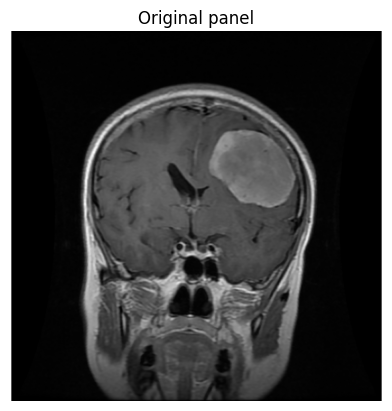

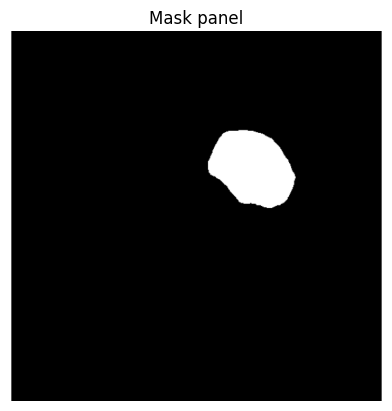

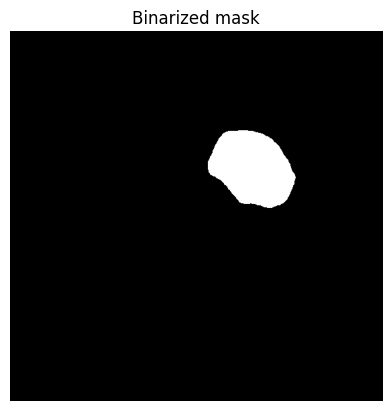

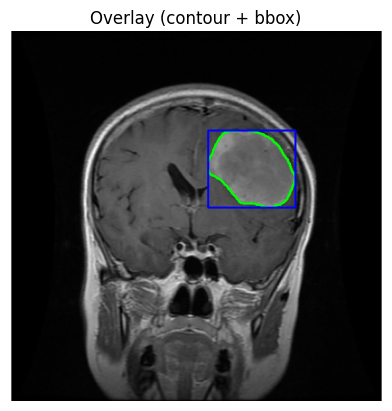

In [13]:
# Preview the split result on one file
import matplotlib.pyplot as plt

test_path = paths[0]
orig, msk = split_composite_png(test_path, debug=True)
mb = binarize_mask(msk)
ov = make_overlay_bgr(orig, mb)

plt.figure()
plt.imshow(orig, cmap="gray")
plt.title("Original panel")
plt.axis("off")
plt.show()

plt.figure()
plt.imshow(msk, cmap="gray")
plt.title("Mask panel")
plt.axis("off")
plt.show()

plt.figure()
plt.imshow(mb, cmap="gray")
plt.title("Binarized mask")
plt.axis("off")
plt.show()

plt.figure()
plt.imshow(cv2.cvtColor(ov, cv2.COLOR_BGR2RGB))
plt.title("Overlay (contour + bbox)")
plt.axis("off")
plt.show()

In [14]:
# OpenAI API key setup
import os, getpass

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter OPENAI_API_KEY: ")

Enter OPENAI_API_KEY: ··········


In [15]:

import json
import numpy as np
from openai import OpenAI

client = OpenAI()

GEN_MODEL = "gpt-4o-mini"
EMB_MODEL = "text-embedding-3-large"

def embed_text(text):
    emb = client.embeddings.create(model=EMB_MODEL, input=text)
    return np.array(emb.data[0].embedding, dtype=np.float32)

def generate_report(case_features: dict, semantic_json: dict, retrieved_case_cards: list) -> str:
    """
    Generate an English, radiology-style report grounded in:
    - case_features (2D screenshot proxy; no pixels)
    - semantic_json (visible facts only)
    - retrieved_case_cards (style only; do not import numbers from them)
    """


    area_pct = case_features.get("lesion_area_pct_of_intracranial_2d")
    diam_pct = case_features.get("lesion_max_diameter_pct_of_intracranial_2d")
    size_cat = case_features.get("size_category_2d")

    loc = semantic_json.get("location_coarse")
    morph = semantic_json.get("morphology") or {}
    shape = morph.get("shape")
    margin = morph.get("margin")
    rel_sig = semantic_json.get("relative_signal_appearance")

    facts = {
        "size_category_2d": size_cat,
        "lesion_area_pct_of_intracranial_2d": area_pct,
        "lesion_max_diameter_pct_of_intracranial_2d": diam_pct,
        "location_coarse": loc,
        "shape": shape,
        "margin": margin,
        "relative_signal_appearance": rel_sig,
        "data_scope_note": "All size metrics are 2D screenshot-based proxies (single slice), not volumetric."
    }

    context = "\n\n---\n\n".join(retrieved_case_cards) if retrieved_case_cards else ""

    prompt = f"""
You are drafting a neuroradiology-style report for RESEARCH USE ONLY.

Hard constraints:
1) Do NOT invent MRI sequences, enhancement, edema, diffusion restriction, hemorrhage, hydrocephalus, midline shift.
2) Do NOT output pixel units or raw pixel numbers.
3) Do NOT write "Not provided", "Not assessed", "Not specified", or "Unknown".
   If a field is missing/unknown, OMIT it entirely.
4) All quantitative statements MUST come only from FACTS_JSON below.
5) Use professional radiology wording, concise and rigorous.

Output MUST contain exactly these section headers (in this order):
Exam
Technique
Findings
Impression
Recommendations
Limitations

FACTS_JSON (use only these facts):
{json.dumps(facts, ensure_ascii=False)}

RETRIEVED_CONTEXT (style only; do not copy numbers from here):
{context}

Writing requirements:
- Findings must be a bullet list.
- Findings must include ONLY the items that are supported by FACTS_JSON and are not null/empty.
  Do NOT include bullets for missing fields.
- Recommendations must be concrete but non-diagnostic (suggest complete MRI sequences + clinical correlation).
- Limitations must explicitly state: screenshot-based, single-slice, 2D proxy not volumetric, no sequence metadata.
"""
    resp = client.responses.create(model=GEN_MODEL, input=prompt)
    return resp.output_text.strip()

In [17]:
# Process top-10 images: split, features, overlay, semantic JSON
import os
import re
import json
import base64
import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm
from openai import OpenAI

client = globals().get("client", None) or OpenAI()
GEN_MODEL = globals().get("GEN_MODEL", "gpt-4o-mini")

os.makedirs(os.path.join(OUT_DIR, "panels"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "overlays"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "reports"), exist_ok=True)


def bgr_to_data_url(img_bgr: np.ndarray) -> str:
    ok, buf = cv2.imencode(".png", img_bgr)
    if not ok:
        raise ValueError("Failed to encode overlay image as PNG.")
    b64 = base64.b64encode(buf.tobytes()).decode("utf-8")
    return f"data:image/png;base64,{b64}"


def default_semantic_json(case_id: str, feats: dict, note: str = "") -> dict:
    has_lesion = bool(feats.get("has_lesion", True))
    return {
        "case_id": case_id,
        "location_coarse": "unknown",
        "morphology": {
            "shape": "unknown",
            "margin": "unknown",
        },
        "relative_signal_appearance": "unknown",
        "lesion_count": 1 if has_lesion else 0,
        "comments_visible_only": note if note else None,
    }


def normalize_semantic_json(sem: dict, case_id: str, feats: dict) -> dict:
    if not isinstance(sem, dict):
        sem = {}

    out = default_semantic_json(case_id, feats)

    out["case_id"] = str(sem.get("case_id", case_id) or case_id)

    loc = sem.get("location_coarse", "unknown")
    if loc not in {"supratentorial", "infratentorial", "unknown"}:
        loc = "unknown"
    out["location_coarse"] = loc

    morph = sem.get("morphology", {})
    if not isinstance(morph, dict):
        morph = {}
    out["morphology"] = {
        "shape": str(morph.get("shape", "unknown") or "unknown"),
        "margin": str(morph.get("margin", "unknown") or "unknown"),
    }

    out["relative_signal_appearance"] = str(
        sem.get("relative_signal_appearance", "unknown") or "unknown"
    )

    lesion_count = sem.get("lesion_count", out["lesion_count"])
    try:
        lesion_count = int(lesion_count)
    except Exception:
        lesion_count = out["lesion_count"]
    out["lesion_count"] = max(0, lesion_count)

    cvo = sem.get("comments_visible_only", None)
    out["comments_visible_only"] = None if cvo is None else str(cvo)

    return out


def extract_json_object(text: str) -> dict:
    text = (text or "").strip()

    if text.startswith("```"):
        text = re.sub(r"^```(?:json)?\s*", "", text)
        text = re.sub(r"\s*```$", "", text)

    try:
        return json.loads(text)
    except Exception:
        pass

    start = text.find("{")
    end = text.rfind("}")
    if start != -1 and end != -1 and end > start:
        return json.loads(text[start:end + 1])

    raise ValueError("No JSON object found in model output.")


def get_semantic_observation_json(overlay_bgr: np.ndarray, feats: dict, case_id: str) -> dict:
    if not feats.get("has_lesion", True):
        return default_semantic_json(
            case_id,
            feats,
            note="No lesion mask detected from the provided segmentation panel."
        )

    facts_for_model = {
        "case_id": case_id,
        "size_category_2d": feats.get("size_category_2d"),
        "lesion_area_pct_of_intracranial_2d": feats.get("lesion_area_pct_of_intracranial_2d"),
        "lesion_max_diameter_pct_of_intracranial_2d": feats.get("lesion_max_diameter_pct_of_intracranial_2d"),
        "circularity": feats.get("circularity"),
        "eccentricity": feats.get("eccentricity"),
        "solidity": feats.get("solidity"),
        "extent": feats.get("extent"),
        "lesion_to_context_mean_ratio": feats.get("lesion_to_context_mean_ratio"),
    }

    prompt = f"""
You are extracting coarse visible observations from a single 2D brain image panel with a segmentation overlay.

Use only what is visually supported by the overlay image and the numeric features.
Do not infer diagnosis.
Do not mention enhancement, edema, hemorrhage, hydrocephalus, midline shift, diffusion restriction, perfusion, spectroscopy, calcification, or pathology subtype.
Be conservative. If uncertain, return "unknown".

Return exactly one JSON object with this schema:
{{
  "case_id": "string",
  "location_coarse": "supratentorial | infratentorial | unknown",
  "morphology": {{
    "shape": "string",
    "margin": "string"
  }},
  "relative_signal_appearance": "string",
  "lesion_count": 1,
  "comments_visible_only": "string or null"
}}

Feature summary:
{json.dumps(facts_for_model, ensure_ascii=False, indent=2)}
""".strip()

    image_url = bgr_to_data_url(overlay_bgr)

    try:
        schema = {
            "type": "object",
            "properties": {
                "case_id": {"type": "string"},
                "location_coarse": {
                    "type": "string",
                    "enum": ["supratentorial", "infratentorial", "unknown"]
                },
                "morphology": {
                    "type": "object",
                    "properties": {
                        "shape": {"type": "string"},
                        "margin": {"type": "string"}
                    },
                    "required": ["shape", "margin"],
                    "additionalProperties": False
                },
                "relative_signal_appearance": {"type": "string"},
                "lesion_count": {"type": "integer"},
                "comments_visible_only": {
                    "anyOf": [{"type": "string"}, {"type": "null"}]
                }
            },
            "required": [
                "case_id",
                "location_coarse",
                "morphology",
                "relative_signal_appearance",
                "lesion_count",
                "comments_visible_only"
            ],
            "additionalProperties": False
        }

        resp = client.responses.create(
            model=GEN_MODEL,
            input=[
                {
                    "role": "user",
                    "content": [
                        {"type": "input_text", "text": prompt},
                        {"type": "input_image", "image_url": image_url, "detail": "high"},
                    ],
                }
            ],
            text={
                "format": {
                    "type": "json_schema",
                    "name": "semantic_observation",
                    "schema": schema,
                    "strict": True,
                }
            },
        )
        sem = json.loads(resp.output_text)
    except Exception:
        resp = client.responses.create(
            model=GEN_MODEL,
            input=[
                {
                    "role": "user",
                    "content": [
                        {"type": "input_text", "text": prompt},
                        {"type": "input_image", "image_url": image_url, "detail": "high"},
                    ],
                }
            ],
        )
        sem = extract_json_object(resp.output_text)

    return normalize_semantic_json(sem, case_id, feats)


all_items = []

for p in tqdm(paths, desc="Processing top-10"):
    fname = os.path.basename(p)
    m = re.search(r"TOP_(\d+)_([^\.]+)\.png", fname)
    rank = int(m.group(1)) if m else None
    case_id = m.group(2) if m else fname.replace(".png", "")
    base = fname.replace(".png", "")

    orig, msk = split_composite_png(p)
    mb = binarize_mask(msk)
    feats = extract_features_2d(orig, mb)

    orig_path = os.path.join(OUT_DIR, "panels", f"{base}_orig.png")
    mask_path = os.path.join(OUT_DIR, "panels", f"{base}_mask.png")
    Image.fromarray(orig).save(orig_path)
    Image.fromarray((mb * 255).astype(np.uint8)).save(mask_path)

    overlay = make_overlay_bgr(orig, mb)
    overlay_path = os.path.join(OUT_DIR, "overlays", f"{base}_overlay.png")
    cv2.imwrite(overlay_path, overlay)

    sem_path = os.path.join(OUT_DIR, "overlays", f"{base}_semantic.json")

    if os.path.exists(sem_path):
        try:
            with open(sem_path, "r", encoding="utf-8") as f:
                sem = json.load(f)
            sem = normalize_semantic_json(sem, case_id, feats)
        except Exception:
            sem = default_semantic_json(case_id, feats, note="Existing semantic JSON could not be loaded.")
            with open(sem_path, "w", encoding="utf-8") as f:
                json.dump(sem, f, ensure_ascii=False, indent=2)
    else:
        try:
            sem = get_semantic_observation_json(overlay, feats, case_id)
        except Exception as e:
            sem = default_semantic_json(
                case_id,
                feats,
                note=f"Semantic generation failed: {type(e).__name__}: {e}"
            )

        with open(sem_path, "w", encoding="utf-8") as f:
            json.dump(sem, f, ensure_ascii=False, indent=2)

    item = {
        "rank": rank,
        "case_id": case_id,
        "file": p,
        "orig_panel": orig_path,
        "mask_panel": mask_path,
        "overlay": overlay_path,
        "features": feats,
        "semantic": sem,
    }
    all_items.append(item)

jsonl_path = os.path.join(OUT_DIR, "features_semantic.jsonl")
with open(jsonl_path, "w", encoding="utf-8") as f:
    for item in all_items:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

print("Done. Items:", len(all_items))
print("Output folder:", OUT_DIR)
print("Saved JSONL:", jsonl_path)

Processing top-10: 100%|██████████| 10/10 [00:41<00:00,  4.16s/it]

Done. Items: 10
Output folder: ./outputs_doc/rag_reports_top10
Saved JSONL: ./outputs_doc/rag_reports_top10/features_semantic.jsonl


In [18]:
# Report generation with KB-RAG support
import os
import json
import numpy as np
from typing import List, Dict, Any
from openai import OpenAI


client = OpenAI()

EMB_MODEL = "text-embedding-3-large"
GEN_MODEL = "gpt-4o-mini"

def embed_text(text: str) -> np.ndarray:
    resp = client.embeddings.create(model=EMB_MODEL, input=text)
    return np.array(resp.data[0].embedding, dtype=np.float32)

def _safe_get(d: Dict[str, Any], path: List[str], default=None):
    cur = d
    for k in path:
        if not isinstance(cur, dict) or k not in cur:
            return default
        cur = cur[k]
    return cur

def build_kb_query_text(case_features: Dict[str, Any], semantic_json: Dict[str, Any]) -> str:
    """
    Build a query text used to retrieve standard templates / terminology / boilerplate guidance.
    """
    size_cat = case_features.get("size_category_2d", "unknown")
    loc = semantic_json.get("location_coarse", "unknown")
    shape = _safe_get(semantic_json, ["morphology", "shape"], "unknown")
    margin = _safe_get(semantic_json, ["morphology", "margin"], "unknown")
    signal = semantic_json.get("relative_signal_appearance", "unknown")

    area_pct = case_features.get("lesion_area_pct_of_intracranial_2d", None)
    diam_pct = case_features.get("lesion_max_diameter_pct_of_intracranial_2d", None)

    parts = [
        "radiology brain lesion report wording",
        f"location: {loc}",
        f"size category: {size_cat}",
        f"shape: {shape}",
        f"margin: {margin}",
        f"relative signal appearance: {signal}",
    ]

    if isinstance(area_pct, (int, float)):
        parts.append(f"approx area percent: {area_pct:.2f}%")
    if isinstance(diam_pct, (int, float)):
        parts.append(f"approx diameter percent: {diam_pct:.2f}%")

    return "; ".join(parts)

def generate_report(case_features: Dict[str, Any],
                    semantic_json: Dict[str, Any],
                    retrieved_kb_docs: List[Dict[str, Any]]) -> str:
    """
    Generate a radiology-style report using ONLY facts from the current case (features + semantic),
    and using KB snippets purely for professional wording and generic guidance.

    retrieved_kb_docs: list of dicts with keys like {id, type, title, text, score}.
    """

    facts = {
        "size_category_2d": case_features.get("size_category_2d", "unknown"),
        "lesion_area_pct_of_intracranial_2d": case_features.get("lesion_area_pct_of_intracranial_2d", None),
        "lesion_max_diameter_pct_of_intracranial_2d": case_features.get("lesion_max_diameter_pct_of_intracranial_2d", None),

        "location_coarse": semantic_json.get("location_coarse", "unknown"),
        "morphology": semantic_json.get("morphology", {}),
        "relative_signal_appearance": semantic_json.get("relative_signal_appearance", "unknown"),

        "lesion_count": semantic_json.get("lesion_count", None),
        "comments_visible_only": semantic_json.get("comments_visible_only", None),
    }

    max_snippets = min(6, len(retrieved_kb_docs))
    kb_pack = []
    for i in range(max_snippets):
        d = retrieved_kb_docs[i]
        kb_pack.append({
            "type": d.get("type", "kb"),
            "title": d.get("title", ""),
            "text": d.get("text", "")
        })

    prompt = f"""
You are a radiology report writer. Write an English radiology-style report based ONLY on FACTS_JSON.
You are also given KB_SNIPPETS (standard templates + terminology + generic recommendation language).
Use KB_SNIPPETS for professional wording, but DO NOT transfer any patient-specific findings from KB_SNIPPETS.

Hard constraints:
- Do NOT invent MRI sequences, contrast enhancement, edema, hemorrhage, mass effect, midline shift, hydrocephalus,
  restricted diffusion, perfusion, spectroscopy, calcification, bone changes, or extracranial findings unless explicitly present in FACTS_JSON.
- If an item is not provided in FACTS_JSON, omit it; do NOT write "unknown", "not provided", or similar placeholders.
- Use approximate language for numeric values (e.g., "approximately X% of intracranial area on this 2D slice").
- Because the input is limited (2D slice + segmentation-derived features), clearly state limitations.

Output format (exact section headers, in this order):
EXAM:
TECHNIQUE:
FINDINGS:
IMPRESSION:
DIFFERENTIAL CONSIDERATIONS:
RECOMMENDATIONS:
LIMITATIONS:

Formatting rules:
- FINDINGS must be bullet points.
- IMPRESSION should be 2-4 short bullets.
- DIFFERENTIAL CONSIDERATIONS must be cautious and conditional ("may include...") and must mention limitations due to missing sequences/clinical history.
- RECOMMENDATIONS should be generic next-steps (e.g., full MRI protocol, clinical correlation), non-urgent, non-directive.

FACTS_JSON:
{json.dumps(facts, ensure_ascii=False, indent=2)}

KB_SNIPPETS:
{json.dumps(kb_pack, ensure_ascii=False, indent=2)}
""".strip()

    resp = client.responses.create(
        model=GEN_MODEL,
        input=prompt
    )
    return resp.output_text

In [19]:
#  Robust KB-RAG retrieval + generate one report per case
import os
import json
import numpy as np
import faiss
from tqdm import tqdm
from typing import List, Dict, Any


assert "OUT_DIR" in globals(), "OUT_DIR is not defined. Define OUT_DIR first."
assert "all_items" in globals(), "all_items is not defined. Run the preprocessing cell that builds all_items first."
assert "embed_text" in globals(), "embed_text is not defined. Run the cell that defines embed_text first."
assert "build_kb_query_text" in globals(), "build_kb_query_text is not defined. Run the cell that defines build_kb_query_text first."
assert "generate_report" in globals(), "generate_report is not defined. Run the cell that defines generate_report first."

os.makedirs(os.path.join(OUT_DIR, "reports"), exist_ok=True)

# KB bootstrap
def build_kb_docs_default() -> List[Dict[str, Any]]:
    """
    Minimal starter KB. Expand this list for better retrieval coverage.
    """
    docs: List[Dict[str, Any]] = []

    docs.append({
        "id": "tpl_brain_lesion_generic",
        "type": "template",
        "title": "Generic brain lesion report phrasing (limited data)",
        "text": (
            "Preferred phrasing:\n"
            "- 'There is a focal lesion in the [location] demonstrating [shape] morphology with [margin] margins.'\n"
            "- 'On this limited 2D slice, the lesion occupies approximately [percent] of intracranial area.'\n"
            "- Use hedged language: 'suggests', 'may represent', 'cannot be fully characterized'.\n"
        )
    })

    docs.append({
        "id": "tpl_findings_style",
        "type": "template",
        "title": "Findings bullet style (radiology tone)",
        "text": (
            "FINDINGS bullet examples:\n"
            "- Location: [supratentorial/infratentorial] compartment.\n"
            "- Size: approximately [qualitative size], ~[percent] intracranial area on this slice.\n"
            "- Morphology: [round/ovoid/irregular] with [well-circumscribed/ill-defined] margins.\n"
            "- Signal: [relative signal appearance] (limited by available sequences).\n"
        )
    })

    docs.append({
        "id": "term_margins",
        "type": "terminology",
        "title": "Margins terminology",
        "text": (
            "Margins:\n"
            "- well-circumscribed\n"
            "- partly ill-defined\n"
            "- ill-defined\n"
            "Avoid implying infiltration unless supported by advanced imaging.\n"
        )
    })

    docs.append({
        "id": "term_shape",
        "type": "terminology",
        "title": "Shape terminology",
        "text": (
            "Shape descriptors:\n"
            "- round, ovoid, lobulated, irregular\n"
        )
    })

    docs.append({
        "id": "ddx_generic_intraaxial",
        "type": "ddx",
        "title": "Differential considerations (generic, limited data)",
        "text": (
            "Differential considerations (conditional, limited by data):\n"
            "- primary glial neoplasm (e.g., glioma)\n"
            "- metastasis\n"
            "- tumefactive demyelination\n"
            "- infection cannot be assessed without DWI/clinical correlation\n"
            "Always state limitations due to missing sequences and clinical history.\n"
        )
    })

    docs.append({
        "id": "rec_full_protocol",
        "type": "recommendation",
        "title": "Recommendation boilerplate",
        "text": (
            "Generic recommendations:\n"
            "- clinical correlation\n"
            "- consider complete brain MRI protocol (T1/T2/FLAIR/DWI/ADC) and post-contrast if clinically indicated\n"
            "- compare with prior imaging if available\n"
            "Keep recommendations non-urgent and non-directive.\n"
        )
    })

    docs.append({
        "id": "limitation_limited_input",
        "type": "template",
        "title": "Limitations language",
        "text": (
            "Limitations language:\n"
            "- 'Interpretation is limited by a single 2D slice and segmentation-derived features.'\n"
            "- 'No multiparametric sequences or clinical history were provided for definitive characterization.'\n"
        )
    })

    return docs


if "kb_docs" not in globals() or not isinstance(globals().get("kb_docs"), list) or len(globals().get("kb_docs")) == 0:
    kb_docs = build_kb_docs_default()

if "kb_index" not in globals():
    kb_texts = [f"{d['title']}\n{d['text']}" for d in kb_docs]
    kb_vecs = np.array([embed_text(t) for t in kb_texts], dtype=np.float32)
    faiss.normalize_L2(kb_vecs)

    dim = kb_vecs.shape[1]
    kb_index = faiss.IndexFlatIP(dim)
    kb_index.add(kb_vecs)

# Persist KB docs
kb_path = os.path.join(OUT_DIR, "kb_docs.jsonl")
with open(kb_path, "w", encoding="utf-8") as f:
    for d in kb_docs:
        f.write(json.dumps(d, ensure_ascii=False) + "\n")

print("KB ready.")
print("KB docs:", len(kb_docs))
print("kb_index ntotal:", kb_index.ntotal)
print("KB saved to:", kb_path)


def retrieve_kb_snippets(query_text: str, k: int = 6) -> List[Dict[str, Any]]:
    """
    Retrieve top-k KB snippets (templates/terminology/ddx/recommendations) using FAISS.
    Requires: kb_docs, kb_index.
    """
    qv = embed_text(query_text).astype(np.float32)[None, :]
    faiss.normalize_L2(qv)

    scores, ids = kb_index.search(qv, k)
    ids = ids[0].tolist()
    scores = scores[0].tolist()

    out: List[Dict[str, Any]] = []
    for idx, sc in zip(ids, scores):
        doc = dict(kb_docs[idx])
        doc["score"] = float(sc)
        out.append(doc)
    return out

# Batch generate reports
reports_summary: List[Dict[str, Any]] = []

for it in tqdm(all_items, desc="Generating reports with KB-RAG"):
    query_text = build_kb_query_text(it["features"], it["semantic"])
    kb_hits = retrieve_kb_snippets(query_text, k=6)

    report_text = generate_report(it["features"], it["semantic"], kb_hits)

    rep_path = os.path.join(OUT_DIR, "reports", f"REPORT_{it['rank']:02d}_{it['case_id']}.txt")
    with open(rep_path, "w", encoding="utf-8") as f:
        f.write(report_text)

    reports_summary.append({
        "rank": it["rank"],
        "case_id": it["case_id"],
        "report_path": rep_path,
        "kb_query": query_text,
        "kb_hits": [
            {"id": d["id"], "type": d["type"], "title": d["title"], "score": d["score"]}
            for d in kb_hits
        ],
    })

index_path = os.path.join(OUT_DIR, "reports_index.json")
with open(index_path, "w", encoding="utf-8") as f:
    json.dump(reports_summary, f, ensure_ascii=False, indent=2)

print("Saved reports:", len(reports_summary))
print("Saved report index to:", index_path)

KB ready.
KB docs: 7
kb_index ntotal: 7
KB saved to: ./outputs_doc/rag_reports_top10/kb_docs.jsonl


Generating reports with KB-RAG: 100%|██████████| 10/10 [01:07<00:00,  6.77s/it]

Saved reports: 10
Saved report index to: ./outputs_doc/rag_reports_top10/reports_index.json


In [20]:
# Build KB
import os
import json
import numpy as np
import faiss
from typing import List, Dict, Any


os.makedirs(os.path.join(OUT_DIR, "reports"), exist_ok=True)

def build_kb_docs() -> List[Dict[str, Any]]:
    """
    A starter knowledge base. Expand this to improve retrieval quality and domain coverage.
    """
    docs: List[Dict[str, Any]] = []

    docs.append({
        "id": "tpl_brain_lesion_generic",
        "type": "template",
        "title": "Generic brain lesion report phrasing (intra-axial, limited data)",
        "text": (
            "Preferred phrasing:\n"
            "- 'There is a focal lesion in the [location] demonstrating [shape] morphology with [margin] margins.'\n"
            "- 'On this limited 2D slice, the lesion occupies approximately [percent] of intracranial area.'\n"
            "- Use hedged language: 'suggests', 'may represent', 'cannot be fully characterized'.\n"
            "Impression patterns:\n"
            "- 'Focal intracranial lesion on limited imaging.'\n"
            "- 'Further characterization recommended with a complete brain MRI protocol (T1/T2/FLAIR/DWI ± post-contrast if indicated).'\n"
        )
    })

    docs.append({
        "id": "tpl_findings_bullets_style",
        "type": "template",
        "title": "Radiology findings bullet style examples",
        "text": (
            "FINDINGS bullet style examples:\n"
            "- Location: [supratentorial/infratentorial] compartment.\n"
            "- Size: approximately [qualitative size], ~[percent] intracranial area on this slice.\n"
            "- Morphology: [round/ovoid/irregular] with [well-circumscribed/ill-defined] margins.\n"
            "- Signal: [relative signal appearance] (limited by available sequences).\n"
        )
    })

    docs.append({
        "id": "term_margins",
        "type": "terminology",
        "title": "Margins terminology (radiology wording)",
        "text": (
            "Margins:\n"
            "- 'well-circumscribed' (sharp interface)\n"
            "- 'partly ill-defined' (partly indistinct interface)\n"
            "- 'ill-defined' (poorly demarcated)\n"
            "Avoid implying infiltration unless supported by advanced imaging.\n"
        )
    })

    docs.append({
        "id": "term_shape",
        "type": "terminology",
        "title": "Shape terminology (radiology descriptors)",
        "text": (
            "Shape descriptors:\n"
            "- 'round', 'ovoid', 'lobulated', 'irregular'\n"
            "Use 'lobulated' for smooth multi-contour bulges; 'irregular' for asymmetric non-smooth contour.\n"
        )
    })

    docs.append({
        "id": "term_location_coarse",
        "type": "terminology",
        "title": "Coarse intracranial location wording",
        "text": (
            "Location wording:\n"
            "- supratentorial: 'supratentorial compartment'\n"
            "- infratentorial: 'posterior fossa / infratentorial compartment'\n"
            "If more specific anatomy is unavailable, keep location coarse.\n"
        )
    })

    docs.append({
        "id": "ddx_generic_intraaxial",
        "type": "ddx",
        "title": "Differential considerations (generic intra-axial lesion, limited data)",
        "text": (
            "Differential considerations (must be conditional, limited by data):\n"
            "- Primary glial neoplasm (e.g., glioma)\n"
            "- Metastasis\n"
            "- Tumefactive demyelination\n"
            "- Infection is not assessable without DWI/clinical correlation\n"
            "Always state: 'Differential is limited by lack of multiparametric sequences and clinical history.'\n"
        )
    })

    docs.append({
        "id": "rec_full_protocol",
        "type": "recommendation",
        "title": "Generic recommendation boilerplate (complete evaluation)",
        "text": (
            "Generic recommendations:\n"
            "- Correlate with clinical history and neurologic examination.\n"
            "- Consider complete brain MRI protocol (T1/T2/FLAIR/DWI/ADC) and post-contrast imaging if clinically indicated.\n"
            "- Consider comparison with prior imaging if available.\n"
            "Keep recommendations non-urgent and non-directive.\n"
        )
    })

    docs.append({
        "id": "limitation_limited_input",
        "type": "template",
        "title": "Limitations language (limited slice-based features)",
        "text": (
            "Limitations language:\n"
            "- 'Interpretation is limited by the availability of a single 2D slice and segmentation-derived features.'\n"
            "- 'No multiparametric sequences or clinical history were provided for definitive characterization.'\n"
        )
    })

    return docs

def embed_texts(text_list: List[str]) -> np.ndarray:
    vecs = []
    for t in text_list:
        vecs.append(embed_text(t))
    return np.array(vecs, dtype=np.float32)

kb_docs = build_kb_docs()
kb_texts = [f"{d['title']}\n{d['text']}" for d in kb_docs]

kb_vecs = embed_texts(kb_texts).astype(np.float32)
faiss.normalize_L2(kb_vecs)

dim = kb_vecs.shape[1]
kb_index = faiss.IndexFlatIP(dim)
kb_index.add(kb_vecs)

kb_path = os.path.join(OUT_DIR, "kb_docs.jsonl")
with open(kb_path, "w", encoding="utf-8") as f:
    for d in kb_docs:
        f.write(json.dumps(d, ensure_ascii=False) + "\n")

print(f"KB docs: {len(kb_docs)} | Saved to: {kb_path}")

KB docs: 8 | Saved to: ./outputs_doc/rag_reports_top10/kb_docs.jsonl


In [21]:
# Retrieve KB snippets and batch-generate reports
import os
import json
import faiss
from tqdm import tqdm
from typing import List, Dict, Any

def retrieve_kb_snippets(query_text: str, k: int = 6) -> List[Dict[str, Any]]:
    qv = embed_text(query_text).astype(np.float32)[None, :]
    faiss.normalize_L2(qv)

    scores, ids = kb_index.search(qv, k)
    ids = ids[0].tolist()
    scores = scores[0].tolist()

    out: List[Dict[str, Any]] = []
    for idx, sc in zip(ids, scores):
        doc = dict(kb_docs[idx])
        doc["score"] = float(sc)
        out.append(doc)
    return out

reports_summary: List[Dict[str, Any]] = []

for it in tqdm(all_items, desc="Generating reports with KB-RAG"):
    query_text = build_kb_query_text(it["features"], it["semantic"])
    kb_hits = retrieve_kb_snippets(query_text, k=6)

    report_text = generate_report(it["features"], it["semantic"], kb_hits)

    rep_path = os.path.join(OUT_DIR, "reports", f"REPORT_{it['rank']:02d}_{it['case_id']}.txt")
    with open(rep_path, "w", encoding="utf-8") as f:
        f.write(report_text)

    reports_summary.append({
        "rank": it["rank"],
        "case_id": it["case_id"],
        "report_path": rep_path,
        "kb_query": query_text,
        "kb_hits": [
            {"id": d["id"], "type": d["type"], "title": d["title"], "score": d["score"]}
            for d in kb_hits
        ]
    })

index_path = os.path.join(OUT_DIR, "reports_index.json")
with open(index_path, "w", encoding="utf-8") as f:
    json.dump(reports_summary, f, ensure_ascii=False, indent=2)

print(f"Saved report index to: {index_path}")

Generating reports with KB-RAG: 100%|██████████| 10/10 [01:03<00:00,  6.31s/it]

Saved report index to: ./outputs_doc/rag_reports_top10/reports_index.json


In [22]:
# Cell AG0
!pip -q install -U ipywidgets
from google.colab import output
output.enable_custom_widget_manager()

import ipywidgets as widgets
from IPython.display import display
display(widgets.HTML("<b>✅ ipywidgets enabled.</b> If you do not see input boxes later, re-run this cell."))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 100.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.


HTML(value='<b>✅ ipywidgets enabled.</b> If you do not see input boxes later, re-run this cell.')

In [32]:
# Cell AG1

import os
import re
import json
import numpy as np
from typing import Dict, Any, List, Callable, Optional
from openai import OpenAI

agent_client = OpenAI()
ROUTER_MODEL = "gpt-4o-mini"
SYNTH_MODEL = "gpt-4o-mini"


def extract_first_json_object(text: str) -> Dict[str, Any]:
    cleaned = re.sub(r"```(?:json)?", "", text, flags=re.IGNORECASE).replace("```", "").strip()
    try:
        obj = json.loads(cleaned)
        if isinstance(obj, dict):
            return obj
    except Exception:
        pass

    m = re.search(r"\{.*\}", cleaned, flags=re.S)
    if not m:
        raise ValueError("No JSON object found in router output.")
    return json.loads(m.group(0))


agent_state = {
    "selected_case_label": None,
    "history": [],
    "_cached_label_to_idx": None,
    "_cached_labels": None,
    "_cached_all_items_len": None,
    "_cached_case_retrieval_texts": None,
    "_cached_case_vecs": None,
}


def build_labels_and_index():
    """
    Build labels and label_to_idx from all_items (cached).
    """
    if "all_items" not in globals() or all_items is None:
        raise RuntimeError("all_items is not defined. Run the preprocessing pipeline first.")

    if (
        agent_state["_cached_all_items_len"] != len(all_items)
        or agent_state["_cached_label_to_idx"] is None
        or agent_state["_cached_labels"] is None
    ):
        labels_local = [f"TOP_{int(it['rank']):02d}_{it['case_id']}" for it in all_items]
        label_to_idx_local = {lab: i for i, lab in enumerate(labels_local)}

        agent_state["_cached_labels"] = labels_local
        agent_state["_cached_label_to_idx"] = label_to_idx_local
        agent_state["_cached_all_items_len"] = len(all_items)

        agent_state["_cached_case_retrieval_texts"] = None
        agent_state["_cached_case_vecs"] = None

    return agent_state["_cached_labels"], agent_state["_cached_label_to_idx"]


def get_case_item(case_label: str) -> Dict[str, Any]:
    _, label_to_idx_local = build_labels_and_index()
    if case_label not in label_to_idx_local:
        raise ValueError(f"Unknown case_label: {case_label}")
    return all_items[label_to_idx_local[case_label]]


def infer_case_label_from_message(msg: str) -> Optional[str]:
    """
    Parse a case label from English-only natural language:
    - exact: TOP_01_402
    - variants: TOP 01 402 / top-01-402
    - rank: top1 / top 1 / case3 / rank10
    """
    labels_local, label_to_idx_local = build_labels_and_index()
    s = msg or ""

    m = re.search(r"(TOP)[ _\-]?(\d{1,2})[ _\-]?([A-Za-z0-9]+)", s, flags=re.IGNORECASE)
    if m:
        lab = f"TOP_{int(m.group(2)):02d}_{m.group(3)}"
        return lab if lab in label_to_idx_local else None

    m2 = re.search(r"(?:top|case|rank)\s*([1-9]|10)\b", s, flags=re.IGNORECASE)
    if not m2:
        m2 = re.search(r"(?:top|case|rank)([1-9]|10)\b", s, flags=re.IGNORECASE)
    if m2:
        r = int(m2.group(1))
        if 1 <= r <= len(labels_local):
            return labels_local[r - 1]

    return None


def make_router_prompt(user_message: str, selected_case_label: Optional[str], detected_case_label: Optional[str]) -> str:
    return f"""
You are a tool router for a neuroradiology reporting agent (research use only).

Return ONLY valid JSON:
{{"plan":[{{"tool":"...","args":{{...}}}}]}}

If no tool is needed, return: {{"plan":[]}}.

State:
- selected_case_label: {selected_case_label}
- detected_case_label_from_text: {detected_case_label}

Available tools:
- list_cases args: {{}}
- select_case args: {{"case_label": string}}
- show_case args: {{"case_label": string (optional)}}
- retrieve_neighbors args: {{"case_label": string (optional), "k": int}}
- generate_report args: {{"case_label": string (optional)}}
- open_report args: {{"case_label": string (optional)}}
- case_facts args: {{"case_label": string (optional)}}

Routing rules:
- If detected_case_label_from_text is not null, include select_case first.
- If user asks for report generation, call generate_report.
- If user asks to show images, call show_case.
- If user asks for similar cases, call retrieve_neighbors.
- If user asks about size/location/shape, call case_facts.
- Otherwise, plan can be empty.

User message:
{user_message}
""".strip()


def _require_case_label(case_label: Optional[str]) -> str:
    if case_label:
        return case_label
    if agent_state.get("selected_case_label"):
        return agent_state["selected_case_label"]
    raise ValueError("No case specified or selected.")


def _ensure_report_pipeline_ready():
    required = ["embed_text", "build_kb_query_text", "retrieve_kb_snippets", "generate_report", "OUT_DIR"]
    missing = [name for name in required if name not in globals()]
    if missing:
        raise RuntimeError(f"Missing required globals for report pipeline: {missing}")


def _case_retrieval_text(it: Dict[str, Any]) -> str:
    feats = it.get("features", {}) or {}
    sem = it.get("semantic", {}) or {}

    if "build_kb_query_text" in globals():
        base = build_kb_query_text(feats, sem)
    else:
        base = ""

    shape = (sem.get("morphology") or {}).get("shape", "unknown")
    margin = (sem.get("morphology") or {}).get("margin", "unknown")

    extra_parts = [
        f"location: {sem.get('location_coarse', 'unknown')}",
        f"shape: {shape}",
        f"margin: {margin}",
        f"relative signal appearance: {sem.get('relative_signal_appearance', 'unknown')}",
        f"size category: {feats.get('size_category_2d', 'unknown')}",
    ]

    area_pct = feats.get("lesion_area_pct_of_intracranial_2d")
    diam_pct = feats.get("lesion_max_diameter_pct_of_intracranial_2d")

    if isinstance(area_pct, (int, float)):
        extra_parts.append(f"lesion area percent: {area_pct:.2f}")
    if isinstance(diam_pct, (int, float)):
        extra_parts.append(f"lesion diameter percent: {diam_pct:.2f}")

    return "; ".join([x for x in [base] + extra_parts if x])


def _build_case_similarity_cache():
    """
    Build per-case retrieval text embeddings for neighbor search.
    Uses current all_items and embed_text.
    """
    if "embed_text" not in globals():
        raise RuntimeError("embed_text is not defined. Run the embedding/report cell first.")

    build_labels_and_index()

    if (
        agent_state["_cached_case_retrieval_texts"] is not None
        and agent_state["_cached_case_vecs"] is not None
        and agent_state["_cached_all_items_len"] == len(all_items)
    ):
        return agent_state["_cached_case_retrieval_texts"], agent_state["_cached_case_vecs"]

    texts = [_case_retrieval_text(it) for it in all_items]
    vecs = np.array([embed_text(t) for t in texts], dtype=np.float32)

    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    vecs = vecs / norms

    agent_state["_cached_case_retrieval_texts"] = texts
    agent_state["_cached_case_vecs"] = vecs
    return texts, vecs


# Tools
def tool_list_cases() -> Dict[str, Any]:
    labels_local, _ = build_labels_and_index()
    return {"cases": labels_local}


def tool_select_case(case_label: str) -> Dict[str, Any]:
    _, label_to_idx_local = build_labels_and_index()
    if case_label not in label_to_idx_local:
        labels_local, _ = build_labels_and_index()
        return {"ok": False, "error": f"Unknown case_label: {case_label}", "available": labels_local}

    agent_state["selected_case_label"] = case_label
    return {"ok": True, "selected_case_label": case_label}


def tool_show_case(case_label: Optional[str] = None) -> Dict[str, Any]:
    cl = _require_case_label(case_label)
    it = get_case_item(cl)
    return {
        "case_label": cl,
        "orig_panel": it["orig_panel"],
        "mask_panel": it["mask_panel"],
        "overlay": it["overlay"],
    }


def tool_retrieve_neighbors(case_label: Optional[str] = None, k: int = 3) -> Dict[str, Any]:
    cl = _require_case_label(case_label)
    labels_local, label_to_idx_local = build_labels_and_index()
    _, vecs = _build_case_similarity_cache()

    idx = label_to_idx_local[cl]
    qv = vecs[idx]
    scores = vecs @ qv
    scores[idx] = -1.0

    topk = min(max(int(k), 1), max(len(labels_local) - 1, 1))
    order = np.argsort(-scores)[:topk]

    neighbors = []
    for j in order.tolist():
        neighbors.append({
            "case_label": labels_local[j],
            "score": float(scores[j]),
        })

    return {
        "case_label": cl,
        "neighbors": neighbors,
    }


def tool_case_facts(case_label: Optional[str] = None) -> Dict[str, Any]:
    cl = _require_case_label(case_label)
    it = get_case_item(cl)

    feats = it.get("features", {}) or {}
    sem = it.get("semantic", {}) or {}

    return {
        "case_label": cl,
        "size_category_2d": feats.get("size_category_2d"),
        "lesion_area_pct_of_intracranial_2d": feats.get("lesion_area_pct_of_intracranial_2d"),
        "lesion_max_diameter_pct_of_intracranial_2d": feats.get("lesion_max_diameter_pct_of_intracranial_2d"),
        "location_coarse": sem.get("location_coarse"),
        "shape": (sem.get("morphology") or {}).get("shape"),
        "margin": (sem.get("morphology") or {}).get("margin"),
        "relative_signal_appearance": sem.get("relative_signal_appearance"),
        "note": "All size metrics are 2D screenshot-based proxies (single slice), not volumetric.",
    }


def tool_generate_report(case_label: Optional[str] = None) -> Dict[str, Any]:
    """
    Generate report using the current KB-RAG pipeline:
    build_kb_query_text -> retrieve_kb_snippets -> generate_report
    """
    _ensure_report_pipeline_ready()

    cl = _require_case_label(case_label)
    it = get_case_item(cl)

    query_text = build_kb_query_text(it["features"], it["semantic"])
    kb_hits = retrieve_kb_snippets(query_text, k=6)
    text = generate_report(it["features"], it["semantic"], kb_hits)

    rep_path = os.path.join(OUT_DIR, "reports", f"REPORT_{int(it['rank']):02d}_{it['case_id']}.txt")
    os.makedirs(os.path.dirname(rep_path), exist_ok=True)
    with open(rep_path, "w", encoding="utf-8") as f:
        f.write(text)

    return {
        "case_label": cl,
        "report_path": rep_path,
        "report_text": text,
        "kb_query": query_text,
        "kb_hits": [
            {
                "id": d.get("id"),
                "type": d.get("type"),
                "title": d.get("title"),
                "score": float(d.get("score", 0.0)),
            }
            for d in kb_hits
        ],
    }


def tool_open_report(case_label: Optional[str] = None) -> Dict[str, Any]:
    cl = _require_case_label(case_label)
    it = get_case_item(cl)

    rep_path = os.path.join(OUT_DIR, "reports", f"REPORT_{int(it['rank']):02d}_{it['case_id']}.txt")
    if not os.path.exists(rep_path):
        return {
            "case_label": cl,
            "ok": False,
            "error": "Report file not found. Generate it first.",
            "report_path": rep_path,
        }

    with open(rep_path, "r", encoding="utf-8") as f:
        text = f.read()

    return {
        "case_label": cl,
        "ok": True,
        "report_path": rep_path,
        "report_text": text,
    }


TOOL_REGISTRY: Dict[str, Callable[..., Dict[str, Any]]] = {
    "list_cases": lambda **kwargs: tool_list_cases(),
    "select_case": lambda case_label, **kwargs: tool_select_case(case_label),
    "show_case": lambda case_label=None, **kwargs: tool_show_case(case_label),
    "retrieve_neighbors": lambda case_label=None, k=3, **kwargs: tool_retrieve_neighbors(case_label, k),
    "case_facts": lambda case_label=None, **kwargs: tool_case_facts(case_label),
    "generate_report": lambda case_label=None, **kwargs: tool_generate_report(case_label),
    "open_report": lambda case_label=None, **kwargs: tool_open_report(case_label),
}

In [33]:
# Cell AG2

import json
from typing import List, Dict, Any, Tuple, Union

def run_plan(plan: Dict[str, Any]) -> List[Dict[str, Any]]:
    trace: List[Dict[str, Any]] = []
    steps = plan.get("plan", [])
    if not isinstance(steps, list):
        raise ValueError("Router plan['plan'] must be a list.")
    for step in steps:
        tool = step.get("tool")
        args = step.get("args", {}) or {}
        if tool not in TOOL_REGISTRY:
            trace.append({"tool": tool, "args": args, "ok": False, "error": "Unknown tool"})
            continue
        try:
            result = TOOL_REGISTRY[tool](**args)
            trace.append({"tool": tool, "args": args, "ok": True, "result": result})
        except Exception as e:
            trace.append({"tool": tool, "args": args, "ok": False, "error": str(e)})
    return trace

def trace_has_tool(trace: List[Dict[str, Any]], name: str) -> bool:
    return any(t.get("ok") and t.get("tool") == name for t in (trace or []))

def extract_case_label_from_trace(trace: List[Dict[str, Any]]) -> str:
    for t in trace or []:
        if t.get("ok") and t.get("tool") in ("select_case","generate_report","open_report","case_facts"):
            r = t.get("result") or {}
            cl = r.get("case_label") or r.get("selected_case_label")
            if isinstance(cl, str) and cl.strip():
                return cl.strip()
    return agent_state.get("selected_case_label") or ""

def extract_report_artifacts(trace: List[Dict[str, Any]]) -> Dict[str, str]:
    """
    Return {"report_path":..., "report_text":...} if available.
    """
    for t in trace or []:
        if t.get("ok") and t.get("tool") in ("generate_report", "open_report"):
            r = t.get("result") or {}
            return {
                "report_path": (r.get("report_path") or "").strip() if isinstance(r.get("report_path"), str) else "",
                "report_text": (r.get("report_text") or "").strip() if isinstance(r.get("report_text"), str) else "",
            }
    return {"report_path": "", "report_text": ""}

def is_report_request(msg: str) -> bool:
    s = (msg or "").lower()
    cn = msg or ""
    return ("generate report" in s) or ("generate a report" in s) or ("make a report" in s) or ("生成报告" in cn) or ("出报告" in cn)

def is_show_request(msg: str) -> bool:
    s = (msg or "").lower()
    cn = msg or ""
    return ("show" in s and ("image" in s or "images" in s)) or ("preview" in s) or ("display" in s) or ("看图" in cn) or ("显示" in cn)

def is_neighbor_request(msg: str) -> bool:
    s = (msg or "").lower()
    cn = msg or ""
    return ("similar" in s) or ("neighbors" in s) or ("nearest" in s) or ("相似" in cn) or ("近邻" in cn)

def needs_case_facts(msg: str) -> bool:
    s = (msg or "").lower()
    cn = msg or ""
    keywords = ["size","large","small","area","percent","percentage","diameter","location","where","shape","margin","tumor","lesion","harm","risk","symptom"]
    cn_kw = ["大小","面积","比例","直径","位置","在哪","形状","边界","肿瘤","病灶","危害","风险","症状","影响"]
    return any(k in s for k in keywords) or any(k in cn for k in cn_kw)

def synthesize_reply_llm(user_message: str, trace: List[Dict[str, Any]]) -> str:
    payload = {
        "selected_case_label": agent_state.get("selected_case_label"),
        "trace": trace,
        "available_cases_count": len(all_items) if ("all_items" in globals() and all_items is not None) else 0,
    }

    prompt = f"""
You are an interactive assistant for a neuroradiology reporting workflow (research use only).
Reply in the same language as the user.

Rules:
- Do NOT ask the user to provide missing clinical details. Use available data.
- Do NOT invent MRI sequences, enhancement, edema, hemorrhage, hydrocephalus, midline shift.
- If case_facts are present, answer directly from them.
- Keep replies concise.

User message:
{user_message}

Tool trace JSON:
{json.dumps(payload, ensure_ascii=False)}
""".strip()

    resp = agent_client.responses.create(model=SYNTH_MODEL, input=prompt)
    return resp.output_text.strip()

def agent_step(
    user_message: str,
    verbose_trace: bool = False,
    return_trace: bool = True
) -> Union[str, Tuple[str, List[Dict[str, Any]]]]:
    agent_state["history"].append({"role": "user", "content": user_message})

    detected = infer_case_label_from_message(user_message)

    plan_steps = []
    if detected:
        plan_steps.append({"tool": "select_case", "args": {"case_label": detected}})


    if is_report_request(user_message):
        if (not detected) and (not agent_state.get("selected_case_label")):
            plan = {"plan": [{"tool": "list_cases", "args": {}}]}
        else:
            plan_steps.append({"tool": "case_facts", "args": {}})
            plan_steps.append({"tool": "generate_report", "args": {}})
            plan = {"plan": plan_steps}

    elif is_show_request(user_message):
        if (not detected) and (not agent_state.get("selected_case_label")):
            plan = {"plan": [{"tool": "list_cases", "args": {}}]}
        else:
            plan_steps.append({"tool": "show_case", "args": {}})
            plan = {"plan": plan_steps}

    elif is_neighbor_request(user_message):
        if (not detected) and (not agent_state.get("selected_case_label")):
            plan = {"plan": [{"tool": "list_cases", "args": {}}]}
        else:
            plan_steps.append({"tool": "retrieve_neighbors", "args": {"k": 3}})
            plan = {"plan": plan_steps}

    elif needs_case_facts(user_message):
        if (not detected) and (not agent_state.get("selected_case_label")):
            plan = {"plan": [{"tool": "list_cases", "args": {}}]}
        else:
            plan_steps.append({"tool": "case_facts", "args": {}})
            plan = {"plan": plan_steps}

    else:
        router_prompt = make_router_prompt(
            user_message=user_message,
            selected_case_label=agent_state.get("selected_case_label"),
            detected_case_label=detected
        )
        router_resp = agent_client.responses.create(model=ROUTER_MODEL, input=router_prompt)
        plan = extract_first_json_object(router_resp.output_text)

    trace = run_plan(plan)


    if trace_has_tool(trace, "generate_report") or trace_has_tool(trace, "open_report"):
        cl = extract_case_label_from_trace(trace)
        art = extract_report_artifacts(trace)
        path = art["report_path"]
        text = art["report_text"]


        if not text and path:
            try:
                r2 = tool_open_report(case_label=cl)
                text = (r2.get("report_text") or "").strip()
            except Exception:
                pass

        reply = f"Report generated for case {cl}.\nReport Path: {path}\n\n=== REPORT START ===\n{text}\n=== REPORT END ==="
    else:
        reply = synthesize_reply_llm(user_message, trace)

    agent_state["history"].append({"role": "assistant", "content": reply})

    if verbose_trace:
        print("=== Plan ===")
        print(json.dumps(plan, ensure_ascii=False, indent=2))
        print("\n=== Trace ===")
        print(json.dumps(trace, ensure_ascii=False, indent=2))
        print("\n=== Reply ===")
        print(reply)

    return (reply, trace) if return_trace else reply

In [34]:
# EVAL Cell 0 — Imports & environment checks
import os, re, time, json, math
import numpy as np
import pandas as pd

def require_global(name: str):
    if name not in globals():
        raise RuntimeError(f"Missing required global: {name}. Please run pipeline/agent cells first.")

for g in ["all_items", "agent_step"]:
    require_global(g)

print("OK: all_items and agent_step are available.")
print("Number of cases:", len(all_items))

OK: all_items and agent_step are available.
Number of cases: 10


In [35]:
# EVAL Cell 1 — Build ground truth table

def make_case_label(it):
    return f"TOP_{int(it['rank']):02d}_{it['case_id']}"

GT = []
for it in all_items:
    feats = it.get("features", {}) or {}
    sem = it.get("semantic", {}) or {}

    gt = {
        "case_label": make_case_label(it),
        "rank": int(it["rank"]),
        "case_id": it["case_id"],
        "has_lesion": bool(feats.get("has_lesion", True)),
        "size_category_2d": feats.get("size_category_2d"),
        "area_pct": feats.get("lesion_area_pct_of_intracranial_2d"),
        "diam_pct": feats.get("lesion_max_diameter_pct_of_intracranial_2d"),
        "location_coarse": sem.get("location_coarse"),
    }
    GT.append(gt)

gt_df = pd.DataFrame(GT).sort_values("rank").reset_index(drop=True)
display(gt_df)

,case_label,rank,case_id,has_lesion,size_category_2d,area_pct,diam_pct,location_coarse
0,TOP_01_402,1,402,True,large,8.455934,29.091959,supratentorial
1,TOP_02_632,2,632,True,moderate,2.151246,14.147832,supratentorial
2,TOP_03_194,3,194,True,very_large,11.909017,36.033651,unknown
3,TOP_04_401,4,401,True,large,8.309933,30.643686,supratentorial
4,TOP_05_223,5,223,True,large,7.206823,24.074692,supratentorial
5,TOP_06_636,6,636,True,large,5.576324,23.088150,supratentorial
6,TOP_07_224,7,224,True,large,7.969249,24.710727,supratentorial
7,TOP_08_12,8,12,True,very_large,25.286786,31.934518,supratentorial
8,TOP_09_637,9,637,True,large,7.597427,26.174763,supratentorial
9,TOP_10_652,10,652,True,large,9.627300,23.844033,supratentorial


In [36]:
# EVAL Cell 2 — Imaging-side checks

VALID_SIZE_CATS = {"small", "moderate", "large", "very_large", "unknown"}
VALID_LOCS = {"supratentorial", "infratentorial", "unknown"}

def check_feature_valid(row):
    if not row["has_lesion"]:
        return True
    area = row["area_pct"]
    if area is None or not isinstance(area, (int, float)) or not (0 < area <= 100):
        return False
    cat = row["size_category_2d"]
    if cat not in VALID_SIZE_CATS:
        return False
    return True

def check_semantic_schema(row):
    loc = row["location_coarse"]
    if loc is not None and loc not in VALID_LOCS:
        return False

    return True

def check_semantic_consistency(row):

    return True

gt_df["feature_valid"] = gt_df.apply(check_feature_valid, axis=1)
gt_df["semantic_schema_ok"] = gt_df.apply(check_semantic_schema, axis=1)
gt_df["semantic_consistent"] = gt_df.apply(check_semantic_consistency, axis=1)

imaging_summary = {
    "feature_valid_rate": float(gt_df["feature_valid"].mean()),
    "semantic_schema_pass_rate": float(gt_df["semantic_schema_ok"].mean()),
    "semantic_consistency_rate": float(gt_df["semantic_consistent"].mean()),
}
print(json.dumps(imaging_summary, indent=2))

{
  "feature_valid_rate": 1.0,
  "semantic_schema_pass_rate": 1.0,
  "semantic_consistency_rate": 1.0
}


In [37]:
# EVAL Cell 3 : KB-RAG retrieval evaluation
import time
import json
import numpy as np
import pandas as pd
import faiss


assert "kb_docs" in globals(), "kb_docs is not defined. Build your KB first."
assert "kb_index" in globals(), "kb_index is not defined. Build your KB FAISS index first."
assert "embed_text" in globals(), "embed_text is not defined."
assert "build_kb_query_text" in globals(), "build_kb_query_text is not defined."
assert "all_items" in globals(), "all_items is not defined."
assert "gt_df" in globals(), "gt_df is not defined (expected from earlier eval cells)."


K = 6

def kb_retrieve(query_text: str, k: int = 6):
    qv = embed_text(query_text).astype(np.float32)[None, :]
    faiss.normalize_L2(qv)
    scores, ids = kb_index.search(qv, k)
    ids = ids[0].tolist()
    scores = scores[0].tolist()
    return ids, scores


def is_limitation_doc(d: dict) -> bool:
    _id = str(d.get("id", "")).lower()
    title = str(d.get("title", "")).lower()
    typ = str(d.get("type", "")).lower()
    return ("limitation" in _id) or ("limitations" in title) or (typ == "limitation")

req_sets = {
    "template": set(i for i, d in enumerate(kb_docs) if str(d.get("type", "")).lower() == "template"),
    "terminology": set(i for i, d in enumerate(kb_docs) if str(d.get("type", "")).lower() == "terminology"),
    "ddx": set(i for i, d in enumerate(kb_docs) if str(d.get("type", "")).lower() == "ddx"),
    "recommendation": set(i for i, d in enumerate(kb_docs) if str(d.get("type", "")).lower() == "recommendation"),
    "limitation": set(i for i, d in enumerate(kb_docs) if is_limitation_doc(d)),
}


req_sets = {k: v for k, v in req_sets.items() if len(v) > 0}
required_keys = list(req_sets.keys())

if len(required_keys) == 0:
    raise RuntimeError("No evaluable KB categories found. Your kb_docs appears empty or untyped.")

oracle_union = set().union(*req_sets.values())

def requirement_coverage(pred_ids):
    satisfied = []
    for rk, s in req_sets.items():
        if any(i in s for i in pred_ids):
            satisfied.append(rk)
    return satisfied

def hit_rate_against_union(pred_ids):
    if len(oracle_union) == 0:
        return 0.0
    return len([i for i in pred_ids if i in oracle_union]) / float(len(pred_ids) if pred_ids else 1)

def mrr_against_union(pred_ids):
    for r, i in enumerate(pred_ids, start=1):
        if i in oracle_union:
            return 1.0 / r
    return 0.0

# Run evaluation over cases
rows = []
t0 = time.time()

n_cases = len(all_items)
for idx in range(n_cases):
    it = all_items[idx]

    query_text = build_kb_query_text(it["features"], it["semantic"])
    pred_ids, pred_scores = kb_retrieve(query_text, k=K)


    satisfied = requirement_coverage(pred_ids)
    coverage = len(satisfied) / float(len(required_keys))

    retrieved = []
    for di, sc in zip(pred_ids, pred_scores):
        d = kb_docs[di]
        retrieved.append({
            "kb_id": d.get("id", ""),
            "type": d.get("type", ""),
            "title": d.get("title", ""),
            "score": float(sc),
        })

    rows.append({
        "case_label": gt_df.loc[idx, "case_label"] if "case_label" in gt_df.columns else f"case_{idx}",
        "kb_query": query_text,
        "required_categories": required_keys,
        "satisfied_categories": satisfied,
        "category_coverage@K": coverage,
        "union_hit_rate@K": hit_rate_against_union(pred_ids),
        "mrr_union": mrr_against_union(pred_ids),
        "retrieved_kb": retrieved,
    })

avg_latency = (time.time() - t0) / max(1, n_cases)

eval_df = pd.DataFrame(rows)


compact_cols = ["case_label", "category_coverage@K", "union_hit_rate@K", "mrr_union"]
display(eval_df[compact_cols])

summary = {
    "K": K,
    "kb_docs_count": int(len(kb_docs)),
    "required_categories": required_keys,
    "avg_category_coverage@K": float(eval_df["category_coverage@K"].mean()),
    "avg_union_hit_rate@K": float(eval_df["union_hit_rate@K"].mean()),
    "avg_mrr_union": float(eval_df["mrr_union"].mean()),
    "avg_retrieval_latency_s": float(avg_latency),
}
print(json.dumps(summary, indent=2))



,case_label,category_coverage@K,union_hit_rate@K,mrr_union
0,TOP_01_402,0.6,1.0,1.0
1,TOP_02_632,0.6,1.0,1.0
2,TOP_03_194,0.8,1.0,1.0
3,TOP_04_401,0.6,1.0,1.0
4,TOP_05_223,0.8,1.0,1.0
5,TOP_06_636,0.6,1.0,1.0
6,TOP_07_224,0.6,1.0,1.0
7,TOP_08_12,0.6,1.0,1.0
8,TOP_09_637,0.6,1.0,1.0
9,TOP_10_652,0.6,1.0,1.0


{
  "K": 6,
  "kb_docs_count": 8,
  "required_categories": [
    "template",
    "terminology",
    "ddx",
    "recommendation",
    "limitation"
  ],
  "avg_category_coverage@K": 0.6399999999999999,
  "avg_union_hit_rate@K": 1.0,
  "avg_mrr_union": 1.0,
  "avg_retrieval_latency_s": 0.3806105852127075
}


In [38]:
# EVAL Cell 4 — Agent tool-use + QA accuracy evaluation

FORBIDDEN_TOKENS = ["px", "pixel", "Not provided", "Not assessed"]

def trace_tools(trace):
    return [t.get("tool") for t in (trace or [])]

def used_tool(trace, name):
    return any(t.get("tool") == name and t.get("ok") for t in (trace or []))

def normalize_text(s):
    return (s or "").lower().strip()

def answer_contains_size(reply, expected_cat):
    r = normalize_text(reply)
    return expected_cat in r

def answer_contains_location(reply, expected_loc):
    r = normalize_text(reply)
    return expected_loc in r

def forbid_check(reply):
    t = reply or ""
    return all(x not in t for x in FORBIDDEN_TOKENS)

def run_agent(msg):
    t0 = time.time()
    reply, trace = agent_step(msg, verbose_trace=False, return_trace=True)
    return reply, trace, time.time() - t0


qa_rows = []
for i in range(len(gt_df)):
    cl = gt_df.loc[i, "case_label"]
    exp_cat = gt_df.loc[i, "size_category_2d"] or "unknown"
    exp_loc = gt_df.loc[i, "location_coarse"] or "unknown"


    if "tool_select_case" in globals():
        tool_select_case(cl)


    reply, trace, dt = run_agent("Is the tumor large?")
    qa_rows.append({
        "case_label": cl,
        "question": "size",
        "latency_s": dt,
        "tools": trace_tools(trace),
        "tool_ok": used_tool(trace, "case_facts"),
        "answer_ok": answer_contains_size(reply, exp_cat) if exp_cat != "unknown" else True,
        "forbid_ok": forbid_check(reply),
    })


    reply, trace, dt = run_agent("Where is the lesion located?")
    qa_rows.append({
        "case_label": cl,
        "question": "location",
        "latency_s": dt,
        "tools": trace_tools(trace),
        "tool_ok": used_tool(trace, "case_facts"),
        "answer_ok": answer_contains_location(reply, exp_loc) if exp_loc != "unknown" else True,
        "forbid_ok": forbid_check(reply),
    })

qa_df = pd.DataFrame(qa_rows)
display(qa_df)

qa_summary = {
    "qa_tool_use_accuracy": float(qa_df["tool_ok"].mean()),
    "qa_answer_accuracy": float(qa_df["answer_ok"].mean()),
    "qa_forbid_pass_rate": float(qa_df["forbid_ok"].mean()),
    "qa_avg_latency_s": float(qa_df["latency_s"].mean()),
}
print(json.dumps(qa_summary, indent=2))

,case_label,question,latency_s,tools,tool_ok,answer_ok,forbid_ok
0,TOP_01_402,size,1.222870,[case_facts],True,True,True
1,TOP_01_402,location,2.800197,[case_facts],True,True,True
2,TOP_02_632,size,0.778728,[case_facts],True,True,True
3,TOP_02_632,location,0.707972,[case_facts],True,True,True
4,TOP_03_194,size,0.836657,[case_facts],True,False,True
5,TOP_03_194,location,0.840626,[case_facts],True,True,True
6,TOP_04_401,size,0.770647,[case_facts],True,True,True
7,TOP_04_401,location,0.836444,[case_facts],True,True,True
8,TOP_05_223,size,0.670673,[case_facts],True,True,True
9,TOP_05_223,location,0.693530,[case_facts],True,True,True


{
  "qa_tool_use_accuracy": 1.0,
  "qa_answer_accuracy": 0.9,
  "qa_forbid_pass_rate": 1.0,
  "qa_avg_latency_s": 0.9061529040336609
}


In [39]:
# EVAL Cell 5 — Report generation evaluation

REQUIRED_SECTIONS = [
    "EXAM:",
    "TECHNIQUE:",
    "FINDINGS:",
    "IMPRESSION:",
    "RECOMMENDATIONS:",
    "LIMITATIONS:",
]

def find_report_path_from_trace(trace):
    for t in trace or []:
        if t.get("ok") and t.get("tool") == "generate_report":
            r = t.get("result") or {}
            p = r.get("report_path")
            if isinstance(p, str) and p.strip():
                return p.strip()
    return ""

def read_text(path):
    if path and os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            return f.read()
    return ""

def report_checks(txt):
    txt_raw = txt or ""
    txt_upper = txt_raw.upper()
    ok_forbid = all(tok.lower() not in txt_raw.lower() for tok in FORBIDDEN_TOKENS)
    ok_sections = all(sec in txt_upper for sec in REQUIRED_SECTIONS)
    return ok_forbid, ok_sections

rep_rows = []
for i in range(len(gt_df)):
    cl = gt_df.loc[i, "case_label"]

    if "tool_select_case" in globals():
        tool_select_case(cl)

    t0 = time.time()

    # Do not hard-code "top 1" here.
    reply, trace = agent_step("Generate report", verbose_trace=False, return_trace=True)

    dt = time.time() - t0

    called = used_tool(trace, "generate_report")
    path = find_report_path_from_trace(trace)
    txt = read_text(path)
    ok_forbid, ok_sections = report_checks(txt) if txt else (False, False)

    rep_rows.append({
        "case_label": cl,
        "latency_s": dt,
        "generate_called": called,
        "report_path": path,
        "file_exists": bool(path and os.path.exists(path)),
        "forbid_ok": ok_forbid,
        "sections_ok": ok_sections,
    })

rep_df = pd.DataFrame(rep_rows)
display(rep_df)

rep_summary = {
    "generate_called_rate": float(rep_df["generate_called"].mean()),
    "report_file_exists_rate": float(rep_df["file_exists"].mean()),
    "report_forbid_pass_rate": float(rep_df["forbid_ok"].mean()),
    "report_sections_pass_rate": float(rep_df["sections_ok"].mean()),
    "report_avg_latency_s": float(rep_df["latency_s"].mean()),
}
print(json.dumps(rep_summary, indent=2))

,case_label,latency_s,generate_called,report_path,file_exists,forbid_ok,sections_ok
0,TOP_01_402,5.134943,True,./outputs_doc/rag_reports_top10/reports/REPORT...,True,True,True
1,TOP_02_632,5.350604,True,./outputs_doc/rag_reports_top10/reports/REPORT...,True,False,True
2,TOP_03_194,6.822794,True,./outputs_doc/rag_reports_top10/reports/REPORT...,True,True,True
3,TOP_04_401,7.212069,True,./outputs_doc/rag_reports_top10/reports/REPORT...,True,True,True
4,TOP_05_223,5.723051,True,./outputs_doc/rag_reports_top10/reports/REPORT...,True,True,True
5,TOP_06_636,7.653506,True,./outputs_doc/rag_reports_top10/reports/REPORT...,True,True,True
6,TOP_07_224,9.967400,True,./outputs_doc/rag_reports_top10/reports/REPORT...,True,True,True
7,TOP_08_12,5.622458,True,./outputs_doc/rag_reports_top10/reports/REPORT...,True,True,True
8,TOP_09_637,4.967179,True,./outputs_doc/rag_reports_top10/reports/REPORT...,True,True,True
9,TOP_10_652,5.906988,True,./outputs_doc/rag_reports_top10/reports/REPORT...,True,True,True


{
  "generate_called_rate": 1.0,
  "report_file_exists_rate": 1.0,
  "report_forbid_pass_rate": 0.9,
  "report_sections_pass_rate": 1.0,
  "report_avg_latency_s": 6.436099338531494
}


In [40]:
# UI Cell — Agent UI
!pip -q install -U gradio

import os
import re
import json
import numpy as np
import pandas as pd
import gradio as gr
from PIL import Image
import faiss
from typing import List, Dict, Any


assert "OUT_DIR" in globals(), "OUT_DIR is not defined."
assert "embed_text" in globals(), "embed_text is not defined."
assert "build_kb_query_text" in globals(), "build_kb_query_text is not defined."
assert "generate_report" in globals(), "generate_report is not defined."
assert "kb_docs" in globals(), "kb_docs is not defined."
assert "kb_index" in globals(), "kb_index is not defined."

os.makedirs(os.path.join(OUT_DIR, "reports"), exist_ok=True)

try:
    from openai import OpenAI
    _client = globals().get("client", None) or OpenAI()
except Exception:
    _client = None

_GEN_MODEL = globals().get("GEN_MODEL", "gpt-4o-mini")


def safe_open_image(path: str):
    if path and isinstance(path, str) and os.path.exists(path):
        try:
            return Image.open(path)
        except Exception:
            return None
    return None

def make_case_label(it: dict) -> str:
    return f"TOP_{int(it['rank']):02d}_{it['case_id']}"

def ensure_all_items() -> list:
    if "all_items" in globals() and isinstance(globals().get("all_items"), list) and len(globals().get("all_items")) > 0:
        return globals()["all_items"]

    jsonl_path = os.path.join(OUT_DIR, "features_semantic.jsonl")
    if not os.path.exists(jsonl_path):
        raise RuntimeError(
            "all_items is not defined and features_semantic.jsonl was not found. "
            "Run the preprocessing cell that builds all_items first."
        )

    items = []
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            row = json.loads(line)

            rank = row.get("rank")
            case_id = row.get("case_id")
            file_path = row.get("file")

            base = os.path.splitext(os.path.basename(file_path))[0] if file_path else f"TOP_{int(rank):02d}_{case_id}"
            orig_panel = os.path.join(OUT_DIR, "panels", f"{base}_orig.png")
            mask_panel = os.path.join(OUT_DIR, "panels", f"{base}_mask.png")

            overlay_path = row.get("overlay")
            if not overlay_path:
                overlay_path = os.path.join(OUT_DIR, "overlays", f"{base}_overlay.png")

            items.append({
                "rank": rank,
                "case_id": case_id,
                "file": file_path,
                "orig_panel": orig_panel,
                "mask_panel": mask_panel,
                "overlay": overlay_path,
                "features": row.get("features", {}),
                "semantic": row.get("semantic", {}),
            })

    globals()["all_items"] = items
    return items

def get_item_by_label(items: list, case_label: str) -> dict:
    for it in items:
        if make_case_label(it) == case_label:
            return it
    return None

def report_path_for_case(it: dict) -> str:
    return os.path.join(OUT_DIR, "reports", f"REPORT_{int(it['rank']):02d}_{it['case_id']}.txt")

def retrieve_kb_snippets(query_text: str, k: int = 6) -> List[Dict[str, Any]]:
    qv = embed_text(query_text).astype(np.float32)[None, :]
    faiss.normalize_L2(qv)
    scores, ids = kb_index.search(qv, k)
    ids = ids[0].tolist()
    scores = scores[0].tolist()

    hits = []
    for idx, sc in zip(ids, scores):
        d = kb_docs[idx]
        hits.append({
            "id": d.get("id", ""),
            "type": d.get("type", ""),
            "title": d.get("title", ""),
            "text": d.get("text", ""),
            "score": float(sc),
        })
    return hits

def kb_hits_to_rows(hits: List[Dict[str, Any]]) -> List[List[Any]]:
    return [[h["type"], h["title"], h["score"], h["id"]] for h in (hits or [])]

def load_case_images(items: list, case_label: str):
    it = get_item_by_label(items, case_label)
    if not it:
        return None, None, None
    orig = safe_open_image(it.get("orig_panel"))
    mask = safe_open_image(it.get("mask_panel"))
    overlay = safe_open_image(it.get("overlay"))
    return orig, mask, overlay

def append_log(chat_log, user_msg: str, assistant_msg: str):
    chat_log = chat_log or []
    chat_log.append({"role": "user", "content": user_msg})
    chat_log.append({"role": "assistant", "content": assistant_msg})
    return chat_log

def parse_case_from_text(text: str, valid_labels: List[str]) -> str:
    if not text:
        return ""
    m = re.search(r"(TOP[_\-\s]?\d{1,2}[_\-\s]?\d+)", text.strip(), flags=re.IGNORECASE)
    if not m:
        return ""
    raw = m.group(1).upper().replace("-", "_").replace(" ", "_")
    m2 = re.match(r"TOP_(\d{1,2})_(\d+)", raw)
    if m2:
        cand = f"TOP_{int(m2.group(1)):02d}_{m2.group(2)}"
        if cand in valid_labels:
            return cand
    if raw in valid_labels:
        return raw
    return ""

def _as_rows(x):
    """
    Normalize gr.Dataframe value to list-of-lists.
    gr.Dataframe may pass a pandas.DataFrame back into callbacks.
    """
    if x is None:
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, pd.DataFrame):
        return x.values.tolist()
    return []


def answer_question_llm(case_label: str, features: dict, semantic: dict, kb_hits: list, question: str) -> str:
    if _client is None:
        return (
            "LLM client is not available (OpenAI not initialized). "
            "You can still use the buttons: Retrieve KB snippets / Generate report."
        )

    facts = {
        "case_label": case_label,
        "features": features or {},
        "semantic": semantic or {},
    }

    kb_meta = [{"type": h.get("type", ""), "title": h.get("title", "")} for h in (kb_hits or [])][:6]

    prompt = f"""
You are a concise radiology assistant.

Use ONLY CASE_FACTS as hard evidence.
KB_SNIPPETS_METADATA is provided ONLY as internal terminology guidance; do NOT quote, copy, or mention it.

Important behavior:
1. If the user asks for POSSIBLE, POTENTIAL, GENERAL, or LIKELY next steps, follow-up tests, management ideas, or treatment considerations,
   you should still provide a cautious answer.
2. In those cases, give 1-2 sentences describing potentially useful or commonly considered next steps that are consistent with the case facts.
3. Make clear that these are general possibilities based on limited imaging facts, not definitive medical instructions.
4. Only say that information is insufficient if absolutely no reasonable general answer can be inferred.
5. Do NOT invent highly specific facts that are not present in CASE_FACTS.

Output requirements:
- Return ONLY the direct answer in 1-2 sentences.
- Do NOT add sections, bullet lists, headings, or extra commentary.
- Do NOT include "Preferred phrasing", "Differential considerations", "Recommendations", or template language.
- If the user asks for possibilities, do NOT refuse unnecessarily.
- Prefer phrasing like:
  "Potentially useful next steps may include ..."
  "Based on the limited case facts, follow-up could include ..."
  "General considerations may include ..."

User question:
{question}

CASE_FACTS (JSON):
{json.dumps(facts, ensure_ascii=False, indent=2)}

KB_SNIPPETS_METADATA (do not quote):
{json.dumps(kb_meta, ensure_ascii=False, indent=2)}
""".strip()

    try:
        resp = _client.responses.create(model=_GEN_MODEL, input=prompt)
        return resp.output_text.strip()
    except Exception:
        resp = _client.chat.completions.create(
            model=_GEN_MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.2,
        )
        return resp.choices[0].message.content.strip()

def try_answer_size_question(features: dict, question: str) -> str:
    q = (question or "").lower()
    if not (("tumor" in q or "lesion" in q) and ("large" in q or "big" in q or "size" in q)):
        return ""

    size_cat = (features or {}).get("size_category_2d", "")
    area_pct = (features or {}).get("lesion_area_pct_of_intracranial_2d", None)

    parts = []
    if size_cat:
        parts.append(f"It is categorized as '{size_cat}'.")
    if isinstance(area_pct, (int, float)):
        parts.append(f"Approximate area is {area_pct:.2f}% of intracranial area on this 2D slice.")
    if not parts:
        return "Insufficient information to determine relative size from the available facts."
    return parts[0] + (" " + parts[1] if len(parts) > 1 else "")

# Agent routing
def agent_step(message: str, selected_case: str, k: int):
    items = ensure_all_items()
    labels = [make_case_label(it) for it in items]

    msg = (message or "").strip()
    lower = msg.lower()

    case_from_text = parse_case_from_text(msg, labels)
    cur_case = case_from_text or selected_case or (labels[0] if labels else "")
    it = get_item_by_label(items, cur_case)
    if not it:
        return cur_case, "Case not found.", [], "", "", ""

    want_kb = any(x in lower for x in ["retrieve kb", "kb snippets", "snippets"])
    want_gen = any(x in lower for x in ["generate report", "write report", "create report"])
    want_open = any(x in lower for x in ["open report", "read report", "show report"])
    want_show = any(x in lower for x in ["show", "image", "case"])
    want_help = any(x in lower for x in ["help", "commands"])

    kb_query = ""
    kb_rows = []
    rep_txt = ""
    rep_path = ""

    if want_help:
        reply = (
            "Try commands:\n"
            "- retrieve kb\n"
            "- generate report\n"
            "- open report\n"
            "- show case\n"
            "Or ask any question."
        )
        return cur_case, reply, kb_rows, kb_query, rep_txt, rep_path

    kb_hits = []
    if want_kb or want_gen:
        kb_query = build_kb_query_text(it["features"], it["semantic"])
        kb_hits = retrieve_kb_snippets(kb_query, k=int(k))
        kb_rows = kb_hits_to_rows(kb_hits)

    if want_gen:
        rep_txt = generate_report(it["features"], it["semantic"], kb_hits)
        rep_path = report_path_for_case(it)
        with open(rep_path, "w", encoding="utf-8") as f:
            f.write(rep_txt)
        return cur_case, f"Report generated for {cur_case}.", kb_rows, kb_query, rep_txt, rep_path

    if want_open:
        rep_path = report_path_for_case(it)
        if os.path.exists(rep_path):
            with open(rep_path, "r", encoding="utf-8") as f:
                rep_txt = f.read()
            return cur_case, f"Opened report for {cur_case}.", kb_rows, kb_query, rep_txt, rep_path
        return cur_case, f"Report not found for {cur_case}. Generate it first.", kb_rows, kb_query, rep_txt, rep_path

    if want_show:
        return cur_case, f"Loaded {cur_case}.", kb_rows, kb_query, rep_txt, rep_path

    fast = try_answer_size_question(it["features"], msg)
    if fast:
        return cur_case, fast, kb_rows, kb_query, rep_txt, rep_path

    kb_query = build_kb_query_text(it["features"], it["semantic"])
    kb_hits = retrieve_kb_snippets(kb_query, k=int(k))
    kb_rows = kb_hits_to_rows(kb_hits)
    reply = answer_question_llm(cur_case, it["features"], it["semantic"], kb_hits, msg)
    return cur_case, reply, kb_rows, kb_query, rep_txt, rep_path


all_items_local = ensure_all_items()
case_labels = [make_case_label(it) for it in all_items_local]
default_case = case_labels[0] if case_labels else ""


def ui_load_case(case_label: str, chat_log):
    items = ensure_all_items()
    orig, mask, overlay = load_case_images(items, case_label)
    chat_log = append_log(chat_log, "load case", f"Loaded {case_label}.")
    return orig, mask, overlay, case_label, [], "", "", "", chat_log, ""

def ui_retrieve_kb(case_label: str, k: int, chat_log):
    items = ensure_all_items()
    it = get_item_by_label(items, case_label)
    if not it:
        chat_log = append_log(chat_log, "retrieve kb", "Case not found.")
        return [], "", chat_log
    q = build_kb_query_text(it["features"], it["semantic"])
    hits = retrieve_kb_snippets(q, k=int(k))
    rows = kb_hits_to_rows(hits)
    chat_log = append_log(chat_log, "retrieve kb", f"Retrieved top-{int(k)} KB snippets for {case_label}.")
    return rows, q, chat_log

def ui_generate_report(case_label: str, k: int, chat_log):
    items = ensure_all_items()
    it = get_item_by_label(items, case_label)
    if not it:
        chat_log = append_log(chat_log, "generate report", "Case not found.")
        return "", "", chat_log
    q = build_kb_query_text(it["features"], it["semantic"])
    hits = retrieve_kb_snippets(q, k=int(k))
    text = generate_report(it["features"], it["semantic"], hits)
    rp = report_path_for_case(it)
    with open(rp, "w", encoding="utf-8") as f:
        f.write(text)
    chat_log = append_log(chat_log, "generate report", f"Generated report for {case_label}.")
    return text, rp, chat_log

def ui_open_report(case_label: str, chat_log):
    items = ensure_all_items()
    it = get_item_by_label(items, case_label)
    if not it:
        chat_log = append_log(chat_log, "open report", "Case not found.")
        return "", "", chat_log
    rp = report_path_for_case(it)
    if not os.path.exists(rp):
        chat_log = append_log(chat_log, "open report", "Report not found. Generate it first.")
        return "", rp, chat_log
    with open(rp, "r", encoding="utf-8") as f:
        text = f.read()
    chat_log = append_log(chat_log, "open report", f"Opened report for {case_label}.")
    return text, rp, chat_log

def ui_clear(case_label: str):
    return [], "", "", "", [], case_label, ""

def ui_chat_send(message: str, chat_log, selected_case: str, k: int,
                 kb_tbl_value, kb_query_value: str, report_txt_value: str, report_path_value: str):
    kb_tbl_rows = _as_rows(kb_tbl_value)

    msg = (message or "").strip()
    if not msg:
        return (
            chat_log, None, None, None,
            kb_tbl_rows,
            (kb_query_value or ""),
            (report_txt_value or ""),
            (report_path_value or ""),
            selected_case,
            ""
        )

    try:
        new_case, reply, kb_rows, kb_query, rep_txt, rep_path = agent_step(msg, selected_case, int(k))

        items = ensure_all_items()
        orig, mask, overlay = load_case_images(items, new_case)

        if kb_rows:
            kb_tbl_rows = kb_rows
        if kb_query:
            kb_query_value = kb_query
        if rep_txt:
            report_txt_value = rep_txt
        if rep_path:
            report_path_value = rep_path

        chat_log = append_log(chat_log, msg, reply)

        return (
            chat_log,
            orig, mask, overlay,
            kb_tbl_rows,
            (kb_query_value or ""),
            (report_txt_value or ""),
            (report_path_value or ""),
            new_case,
            ""
        )
    except Exception as e:
        chat_log = append_log(chat_log, msg, f"Backend error: {type(e).__name__}: {e}")
        return (
            chat_log,
            None, None, None,
            kb_tbl_rows,
            (kb_query_value or ""),
            (report_txt_value or ""),
            (report_path_value or ""),
            selected_case,
            ""
        )


custom_css = """
html, body, .gradio-container {
    background: #0b1220 !important;
    color: #e5e7eb !important;
    font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, "Helvetica Neue",
                 Arial, "Noto Sans", sans-serif !important;
    font-style: normal !important;
    letter-spacing: normal !important;
}

.gradio-container,
.gradio-container * {
    font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, "Helvetica Neue",
                 Arial, "Noto Sans", sans-serif !important;
    text-shadow: none !important;
}

/* Panels / cards */
.gradio-container .block,
.gradio-container .gr-block,
.gradio-container .gr-panel,
.gradio-container .panel,
.gradio-container .wrap,
.gradio-container .form,
.gradio-container .gr-form,
.gradio-container .gr-box,
.gradio-container fieldset {
    background: #111827 !important;
    color: #e5e7eb !important;
    border: 1px solid #374151 !important;
    box-shadow: none !important;
    border-radius: 12px !important;
}

/* Headings / labels / markdown */
.gradio-container .prose,
.gradio-container .prose *,
.gradio-container .md,
.gradio-container .md *,
.gradio-container label,
.gradio-container legend,
.gradio-container h1,
.gradio-container h2,
.gradio-container h3,
.gradio-container h4,
.gradio-container p,
.gradio-container span,
.gradio-container div {
    color: #e5e7eb !important;
}

/* Buttons */
.gradio-container button {
    background: #1f2937 !important;
    color: #f9fafb !important;
    border: 1px solid #4b5563 !important;
    box-shadow: none !important;
    font-weight: 600 !important;
}
.gradio-container button:hover {
    background: #273449 !important;
    border-color: #60a5fa !important;
}
.gradio-container button.primary,
.gradio-container .primary,
.gradio-container [variant="primary"] {
    background: #3155e7 !important;
    color: #ffffff !important;
    border: 1px solid #3155e7 !important;
}
.gradio-container button.primary *,
.gradio-container .primary *,
.gradio-container [variant="primary"] * {
    color: #ffffff !important;
}

/* Inputs */
.gradio-container input,
.gradio-container textarea,
.gradio-container select {
    background: #0f172a !important;
    color: #f3f4f6 !important;
    border: 1px solid #475569 !important;
    box-shadow: none !important;
    line-height: 1.55 !important;
    font-size: 15px !important;
    border-radius: 8px !important;
}
.gradio-container input::placeholder,
.gradio-container textarea::placeholder {
    color: #94a3b8 !important;
}

/* Read-only text boxes */
.gradio-container textarea[readonly],
.gradio-container input[readonly],
.gradio-container .gr-textbox textarea,
.gradio-container .gr-textbox input {
    background: #111827 !important;
    color: #f3f4f6 !important;
    border: 1px solid #374151 !important;
    font-weight: 400 !important;
}

/* Tables / dataframe */
.gradio-container table {
    background: #111827 !important;
    color: #e5e7eb !important;
    border-collapse: collapse !important;
}
.gradio-container thead,
.gradio-container tbody,
.gradio-container tr,
.gradio-container th,
.gradio-container td {
    background: #111827 !important;
    color: #e5e7eb !important;
    border: 1px solid #374151 !important;
    font-size: 14px !important;
}
.gradio-container thead th {
    background: #1f2937 !important;
    color: #f9fafb !important;
}
.gradio-container tbody tr:nth-child(even) td {
    background: #0f172a !important;
}

/* Chat container */
#chatbot {
    background: #0f172a !important;
    border: 1px solid #374151 !important;
    border-radius: 12px !important;
}

/* Assistant bubble */
#chatbot .message,
#chatbot .message.assistant,
#chatbot .message.bot {
    background: #1f2937 !important;
    color: #f3f4f6 !important;
    border: none !important;
    box-shadow: none !important;
    border-radius: 16px !important;
}

/* User bubble */
#chatbot .message.user {
    background: #3155e7 !important;
    color: #ffffff !important;
    border: none !important;
    box-shadow: none !important;
    border-radius: 16px !important;
}

/* Remove inner box inside user bubble */
#chatbot .message.user > div,
#chatbot .message.user > div > div,
#chatbot .message.user > div > div > div,
#chatbot .message.user .message-content,
#chatbot .message.user .message-wrap,
#chatbot .message.user .message-markdown,
#chatbot .message.user .message-markdown p,
#chatbot .message.user .message-markdown span {
    background: transparent !important;
    border: none !important;
    box-shadow: none !important;
    outline: none !important;
}

/* Bubble text colors */
#chatbot .message *,
#chatbot .message.assistant *,
#chatbot .message.bot * {
    color: #f3f4f6 !important;
}
#chatbot .message.user * {
    color: #ffffff !important;
}

/* Icon buttons */
.gradio-container .icon-button,
.gradio-container .copy-button,
.gradio-container [role="button"] {
    color: #e5e7eb !important;
}

/* Image blocks */
.gradio-container img {
    background: #111827 !important;
}

/* Scrollbars */
*::-webkit-scrollbar {
    height: 10px;
    width: 10px;
}
*::-webkit-scrollbar-track {
    background: #0f172a;
}
*::-webkit-scrollbar-thumb {
    background: #475569;
    border-radius: 999px;
}
"""

# Build UI
with gr.Blocks() as demo:
    gr.Markdown("# KB-RAG Radiology Report Agent UI (Top-10 Cases)")

    with gr.Row():
        with gr.Column(scale=1):
            case_dd = gr.Dropdown(choices=case_labels, value=default_case, label="Case")
            k_slider = gr.Slider(1, 12, value=6, step=1, label="KB Top-K")

            btn_load = gr.Button("Load case")
            btn_kb = gr.Button("Retrieve KB snippets")
            btn_gen = gr.Button("Generate report")
            btn_open = gr.Button("Open report")
            btn_clear = gr.Button("Clear")

        with gr.Column(scale=2):
            with gr.Row():
                orig_img = gr.Image(label="Original", height=320)
                mask_img = gr.Image(label="Mask", height=320)
                overlay_img = gr.Image(label="Overlay", height=320)
            selected_case = gr.Textbox(label="Selected case", interactive=False, value=default_case)

    with gr.Row():
        kb_query_box = gr.Textbox(label="KB query text", lines=2, interactive=False)

    with gr.Row():
        kb_tbl = gr.Dataframe(
            headers=["type", "title", "score", "id"],
            label="Retrieved KB snippets",
            interactive=False
        )

    with gr.Row():
        report_txt = gr.Textbox(label="Report text", lines=18, interactive=False)

    with gr.Row():
        report_path = gr.Textbox(label="Report path", interactive=False)

    gr.Markdown("## Agent Chat (free-form questions supported; concise answers)")
    chat_log = gr.Chatbot(label="Chat", height=420, elem_id="chatbot")
    user_in = gr.Textbox(label="Message", placeholder="Ask anything. Example: Is this tumor large?")
    btn_send = gr.Button("Send", variant="primary")

    btn_load.click(
        fn=ui_load_case,
        inputs=[case_dd, chat_log],
        outputs=[orig_img, mask_img, overlay_img, selected_case, kb_tbl, kb_query_box, report_txt, report_path, chat_log, user_in],
    )

    btn_kb.click(
        fn=ui_retrieve_kb,
        inputs=[case_dd, k_slider, chat_log],
        outputs=[kb_tbl, kb_query_box, chat_log],
    )

    btn_gen.click(
        fn=ui_generate_report,
        inputs=[case_dd, k_slider, chat_log],
        outputs=[report_txt, report_path, chat_log],
    )

    btn_open.click(
        fn=ui_open_report,
        inputs=[case_dd, chat_log],
        outputs=[report_txt, report_path, chat_log],
    )

    btn_clear.click(
        fn=ui_clear,
        inputs=[selected_case],
        outputs=[kb_tbl, kb_query_box, report_txt, report_path, chat_log, selected_case, user_in],
    )

    btn_send.click(
        fn=ui_chat_send,
        inputs=[user_in, chat_log, selected_case, k_slider, kb_tbl, kb_query_box, report_txt, report_path],
        outputs=[chat_log, orig_img, mask_img, overlay_img, kb_tbl, kb_query_box, report_txt, report_path, selected_case, user_in],
    )

    user_in.submit(
        fn=ui_chat_send,
        inputs=[user_in, chat_log, selected_case, k_slider, kb_tbl, kb_query_box, report_txt, report_path],
        outputs=[chat_log, orig_img, mask_img, overlay_img, kb_tbl, kb_query_box, report_txt, report_path, selected_case, user_in],
    )

    demo.load(
        fn=ui_load_case,
        inputs=[case_dd, chat_log],
        outputs=[orig_img, mask_img, overlay_img, selected_case, kb_tbl, kb_query_box, report_txt, report_path, chat_log, user_in],
    )

demo.launch(debug=True, share=True, css=custom_css)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://52c4429656e56429a9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://52c4429656e56429a9.gradio.live
